# Recall Analysis

This Notebook Aims at Analysing the Data from Recall Experiments. Computing Various Data Features of Recall Texts 


### Parameters 

In [1]:
### Imports
import matplotlib.pyplot as plt

EXPNAME = "secondExp"    # Name of the ERxperiment in Quesion


### Parameters and Globals
CLASSN = 4                       # Number of MW Discrete Classess - Use it to 4 - easier for now, most measures can be aggregated later
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy to understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

CONTINUE = False   # Whether we want to ascribe NEW data to previous DataFrame or re-analyse them as they are 
VERBOSE = True     # Verbosity - How much of an output out of this analysis do we want?
LOADREADY = True   # Preffered Option - It loads already ready df_Data that was screened 
# FIlteri Data Parameters
SUBJECTS = "all"   # If we want to process all the subjects or single out in a list those that are to be removed - Default - ALL SUBJECTS
SHORTLEMMAS = True   # Whether to include Utterances that have simple to little Lemmas


VIZFOLDER = f"FINAL_extrF_{CLASSN}_{SHORTLEMMAS}_{SUBJECTS}"


### Load Data

Logic is this: 
- If we want to continue- we simply get the subjects that are already processed and Process from zero only those not processed!
- If we want to read the dfData and then preprocess them to get analysis, we simply read it and do it all over again! 

In [2]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 
import pickle

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,EXPNAME,'Recalls')       # Save Path for Recall results
savePathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER)

if os.path.isdir(savePathFeatures) == 0:
    os.makedirs(savePathFeatures) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())


###  If We want to Continue giving new data and Not lto label we sfhall; use Topic Classifier to ascribe classess to the new Data: 
if CONTINUE and not LABELING:
    with open(os.path.join(workingDir,EXPNAME,"RecallAnalysis","topic_model_logreg.pkl"), "rb") as f:
        classifModel = pickle.load(f)

### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(savePathFeatures,"data.xlsx"), index_col=0)

### Create other Data Frames
#if not os.path.isfile(os.path.join(savePathFeatures,"features.xlsx")) or not CONTINUE:
dfAnalysis = dfData[['Subject','Fragment','Attention','utt_leng']] # Data Frame for Analysis

    

### Change Classess for a 2 way classification:
#### RE-Teaching on Binary Classification: 
if CLASSN == 2:
    dfData = reLabel(dfData,renameDict={1:1,1:2,3:3,3:4})
    dfData = reLabel(dfData,renameDict={1:1,2:3})
    CLASSESS =  {1:"Focus", 2:"Mind Wandering"}




c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
From c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tf_keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



In [3]:
dfData['Sentences'].apply(lambda x: len(x)).describe()

count    1125.000000
mean      199.066667
std        99.720437
min        32.000000
25%       126.000000
50%       184.000000
75%       252.000000
max       558.000000
Name: Sentences, dtype: float64

## Preprocessing 

This Part of Code Gathers Data and Functions that are Paramount for Analysis

Here we preprocess our data so it would be clean for our future Analsis and Teaching: 
0. Load Data
1. Create Labels - (Optional)
2. Loading ALL Recall Texts - Gathering all Corpus Data
3. Loading All Stories
4. Making Morphological Entities extraction from Both Stories and Recalls

### Load data 

Here we load our data and creatre dfAnalysis if necessery: 



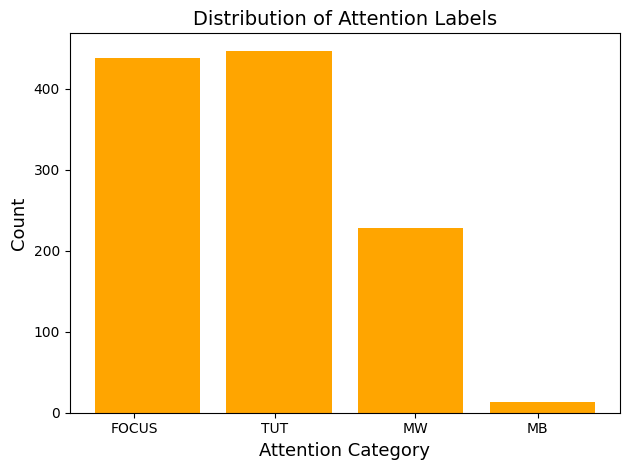

% of FOCUS: 0.39 (N: 438)
% of TRT:   0.40 (N: 446)
% of MW:    0.20 (N: 228)
% of MB:    0.01 (N: 13)


<Figure size 640x480 with 0 Axes>

In [3]:
import ast

if not LOADREADY:
    def fillDfData(dfData,savePathRecall):
        labeledSubjects = dfData['Subject'].unique()
        subjR = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]

        from IPython.display import clear_output
        if LABELING:
            answer = []
            answDict = {}
            answrScheme = {v: k for k, v in CLASSESS.items()}

        subjList     = []
        fragmentList = []
        rawCorpus    = []
        answDict = {}
        answer = []

        for sn,s in enumerate(subjR):

            textfiles = [f for f in os.listdir(os.path.join(savePathRecall, s)) if f.endswith('.txt') and 'recall_' in f[:7] and "KASIA" not in f]
            answDict[s] = []
            if CONTINUE and (s in labeledSubjects): # Label only unlabeled Subjects - Creates a NEW DataFrame
                print(f"{s}: This Subject have been analysed already")
                continue
            
            for t in textfiles:
                text_file =  open(os.path.join(savePathRecall,s,t), "r+",encoding="utf-8")
                fragmentList.append(os.path.splitext(t)[0])
                subjList.append(s)

                
                for line in text_file: # One Text - One Line: Always! - thats why it worrks although it looks INCREDIBELY SKETCHY
                    rawCorpus.append(line) 
                    print(line)
                    if LABELING:
                        print(f"Text of {os.path.splitext(t)[0]} from {s}",flush=True)
                        print(line,flush=True)
                        ans = input()
                        answer.append(ans)
                        answDict[s].append(ans)
                        clear_output()
                    else:
                        if CONTINUE: # IF no labeling BUT continue, means that We need to fill by Blanks
                            answer.append(None)
                        else: # If No Labeling and No continue, we need to fill previous iteration from our DF
                            print(s,t)
                            if np.sum((dfData['Subject'] ==s) & (dfData['Fragment'] == os.path.splitext(t)[0])):
                                answer.append(dfData['Attention'][(dfData['Subject'] ==s) & (dfData['Fragment'] == os.path.splitext(t)[0])].values[0])
                            else:
                                answer.append(None)
        import pandas as pd
        if len(rawCorpus): #If there are  New Subjects
            dfData= pd.DataFrame([subjList,fragmentList,answer,rawCorpus],index = ["Subject","Fragment","Attention","Utterance"]).transpose()
            dfData['utt_leng'] = [len(t) for t in dfData['Utterance'].values]
            dfAnalysis = dfData[['Subject','Fragment','Attention','utt_leng']] # Data Frame for Analysis

        else:

            ### Change String into a list
            for cl in dfData.drop(columns=['Subject', 'Fragment','Utterance','Tracking','StoryFrag']).columns:
                if type(dfData[cl].values[0]) is str:
                    dfData[cl] = dfData[cl].apply(ast.literal_eval)
            rawCorpus =  list(dfData['Utterance'])

        return rawCorpus,dfData,dfAnalysis,subjList,fragmentList,labeledSubjects

    rawCorpus,dfData,dfAnalysis,subjList,fragmentList,labeledSubjects =  fillDfData(dfData,savePathRecall)
else:
    rawCorpus =  list(dfData['Utterance'])       # Corpus made from List of DS
    subjList = []                                # List of subjects FOR preprocessing - empty because we are only concerend with current subjects
    labeledSubjects = dfData['Subject'].unique() # all labeled subejcst
    fragmentList =  list(dfData['Fragment'])


### Plot of Attentional Distribution
if not np.sum(dfData['Attention'].isna()):
    plt.hist(dfData['Attention'], bins=4, rwidth=0.8, color="orange")

    # Custom tick labels centered on bins
    plt.xticks([1.3,2.1,2.9,3.6],labels=["FOCUS", "TUT", "MW", "MB"])

    # Add labels and title
    plt.xlabel("Attention Category", fontsize=13)
    plt.ylabel("Count", fontsize=13)
    plt.title("Distribution of Attention Labels", fontsize=14)

    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(savePathFeatures,"attDist.png"))
    attGroups =  dfData.groupby('Attention')['Attention'].count()
    print(f"% of FOCUS: {attGroups.loc[1]/len(dfData):.2f} (N: {attGroups.loc[1]})")
    print(f"% of TRT:   {attGroups.loc[2]/len(dfData):.2f} (N: {attGroups.loc[2]})")

    print(f"% of MW:    {attGroups.loc[3]/len(dfData):.2f} (N: {attGroups.loc[3]})")
    print(f"% of MB:    {attGroups.loc[4]/len(dfData):.2f} (N: {attGroups.loc[4]})")

    # Create a df_analysis_check (Where the Average Differences in Features across Different Measures WIll be stored)
    df_Analysis_Checks = dfAnalysis.groupby("Attention")[['utt_leng']].agg(['min', 'max', 'mean', 'std']).transpose() # Attention 

    ### Create a df for Descritpive stats of Data :
    df_Subject_Checks = dfData.groupby(['Subject', 'Attention']).size().unstack(fill_value=0).astype(int) # Attention
    uttLeng = dfData.groupby("Subject")['utt_leng'].describe() ### Desciribe of Story Length
    df_Subject_Checks = pd.concat([df_Subject_Checks.astype(int), uttLeng], axis=1, keys=['Attention Desc', 'Utterance Leng Desc']).transpose()
    df_Subject_Checks

### (0.1) Extracting Morphological Features:

Here we extract Lemmas, sentences and Phrases out of our Raw texts AND story Fragments to use in computing Featurwes

Firswt things first we **EXTRACT LEMMAS** and other Lingusitic entites:

1. Extract Morphological Analysis Values:

        For Lemma extraction- using Morfeusz + Concraft - Preffered - minor mistakes needing a manual refraction! 
        For Noun/Verb phrases - Spacy - Easier to get more similar close phrases to an original text!
2. Extracting raw semantic Features :

        Lemmatized Tokens
        Noun Phrases
        Verb, and Action Orineted Phrases



In [4]:
#### ---- SPACY BASED ------ #####

### Load Spacy Engine and Morfeusz!
import spacy
NLP = spacy.load("pl_core_news_lg")
from storyTools import spacyMorph
import morfeusz2
morf = morfeusz2.Morfeusz()


### Load Dictionairy Stemmer based on Morfeusz togeter with 
from storyTools import dictStemmer,lems,preNorm

all_Lemas = [];
all_Verb = [];
all_Noun = [];
all_Sentences = [];


for i,t in enumerate(dfData['Utterance']):

    ### Continiue if subject was already processed 
    if len(subjList) !=0:
        if CONTINUE and (subjList[i] in labeledSubjects):
            continue
    if VERBOSE:
        print(f"Processing: {dfData['Subject'].iloc[i]}//{dfData['Fragment'].iloc[i]}")

    ### Get rid of Empty Lemma:
    verb_phrases,noun_phrases,lemmas,sentences = spacyMorph(t,NLP,morf,polish_stopwords)
    lemmas    = list(filter(lambda a: a != ' ', lemmas))        # Filter out Empty Sequences
    sentences = list(filter(lambda a: a != ' ', sentences))     # Filter out Empty Sequences

    all_Sentences.append(sentences)
    all_Lemas.append(lemmas)
    all_Verb.append(verb_phrases)
    all_Noun.append(noun_phrases)


dfData['Sentences'] = all_Sentences;
dfData['Lemmas']    = all_Lemas;
dfData['Verbs']     = all_Verb;
dfData['Nouns']     = all_Noun;

#### Gathering ALL Lemmas in a single List
allLemas = []
for t in dfData['Lemmas'].values:  
    allLemas = allLemas + t

### Getting ALL subject Lemmas in a single List
SLemmas = []
for s in dfData['Subject'].unique():
    currLemmas = []
    for t in dfData[dfData['Subject'] == s]['Lemmas'].values:
        currLemmas = currLemmas + t
    SLemmas.append(currLemmas)


Processing: ADNA2507//recall_JANEK_1
Processing: ADNA2507//recall_JANEK_10
Processing: ADNA2507//recall_JANEK_11
Processing: ADNA2507//recall_JANEK_12
Processing: ADNA2507//recall_JANEK_13
Processing: ADNA2507//recall_JANEK_14
Processing: ADNA2507//recall_JANEK_15
Processing: ADNA2507//recall_JANEK_16
Processing: ADNA2507//recall_JANEK_17
Processing: ADNA2507//recall_JANEK_18
Processing: ADNA2507//recall_JANEK_19
Processing: ADNA2507//recall_JANEK_2
Processing: ADNA2507//recall_JANEK_20
Processing: ADNA2507//recall_JANEK_3
Processing: ADNA2507//recall_JANEK_4
Processing: ADNA2507//recall_JANEK_5
Processing: ADNA2507//recall_JANEK_6
Processing: ADNA2507//recall_JANEK_7
Processing: ADNA2507//recall_JANEK_8
Processing: ADNA2507//recall_JANEK_9
Processing: ADNA2507//recall_KAROLINA_1
Processing: ADNA2507//recall_KAROLINA_10
Processing: ADNA2507//recall_KAROLINA_11
Processing: ADNA2507//recall_KAROLINA_12
Processing: ADNA2507//recall_KAROLINA_13
Processing: ADNA2507//recall_KAROLINA_14
Proc

### (0.2) Load Story Fragments And Their Analyses


This part of a code is trying to extract lemmas out of story fragments for Comparisons sake and computation of similarity of a recall to fragment



In [5]:
import numpy as np
### Load Stories and differentiate between entitites
[Story1,Story1_raw] = loadStory("story3.txt")
Story1_bundle = splitStoryEntity(Story1_raw)
karolinaStory = Story1_bundle['firstEntity']
janekStory = Story1_bundle['secondEntity']
entityTracked = [];
### Load Tracked Entity Name for Subjects: 
# Get the tracked entity name and display parameters (TBD)

### FOR NOW!!!! 

if LOADREADY:
    siter = dfData['Subject']
else:
    siter= subjList
for s in list(np.unique(list(siter))):
    with open(os.path.join(os.path.split(workingDir)[0] + "\\data_second", s,s + '_log.txt'), 'r') as fp:
        for line in fp:
            if "Current Named Entity" in line:
                entityTracked.append(line.split("Current Named Entity: ")[1].strip())
                break

StrackingDF = pd.DataFrame({
    "Entity": entityTracked,
    "Subject": list(np.unique(list(siter)))
})


#### Get Lemmatization of Story Fragments:

kSentences = []
kLemmas = []
jSentences = []
jLemmas = []
for i,t in enumerate(karolinaStory):
    docK = NLP(karolinaStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    kSentences.append([sent.text for sent in docK.sents])
    kLemmas.append( dictStemmer(karolinaStory[i],morf,norms=preNorm,lems=lems))
for i,t in enumerate(janekStory):
    docJ = NLP(janekStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    jSentences.append([sent.text for sent in docJ.sents])
    jLemmas.append( dictStemmer(janekStory[i],morf,norms=preNorm,lems=lems))




### Mark Fragments as Tracked or Untracked 
storyFrag = []
allTracking = []
storySentences = []
storyLemmas = []
jit = 0
kit = 0
for i in range(len(dfData)):
    if VERBOSE:
        print(f"Processing: {siter[i]}//{fragmentList[i]}")
    currS = dfData['Subject'].iloc[i]
    trackedEntity = StrackingDF[StrackingDF['Subject'] == currS]['Entity'].values[0]
    if trackedEntity in dfData['Fragment'].iloc[i]:
        allTracking.append("TRACKED")
    else:
        allTracking.append("UNTRACKED")

    ### Add Janek and Karolina Story Fragments Respectively with their Lemmatizations and Sentences
    if "JANEK" in dfData['Fragment'].iloc[i]: 
        storyFrag.append(janekStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(jSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(jLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
    else:
        storyFrag.append(karolinaStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(kSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(kLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])

dfData['Tracking']  = allTracking
dfData['StoryFrag'] = storyFrag
dfAnalysis['Tracked'] = allTracking

dfData['StorySentences']  = storySentences
dfData['StoryLemmas']     = storyLemmas


Processing: ADNA2507//recall_JANEK_1
Processing: ADNA2507//recall_JANEK_10
Processing: ADNA2507//recall_JANEK_11
Processing: ADNA2507//recall_JANEK_12
Processing: ADNA2507//recall_JANEK_13
Processing: ADNA2507//recall_JANEK_14
Processing: ADNA2507//recall_JANEK_15
Processing: ADNA2507//recall_JANEK_16
Processing: ADNA2507//recall_JANEK_17
Processing: ADNA2507//recall_JANEK_18
Processing: ADNA2507//recall_JANEK_19
Processing: ADNA2507//recall_JANEK_2
Processing: ADNA2507//recall_JANEK_20
Processing: ADNA2507//recall_JANEK_3
Processing: ADNA2507//recall_JANEK_4
Processing: ADNA2507//recall_JANEK_5
Processing: ADNA2507//recall_JANEK_6
Processing: ADNA2507//recall_JANEK_7
Processing: ADNA2507//recall_JANEK_8
Processing: ADNA2507//recall_JANEK_9
Processing: ADNA2507//recall_KAROLINA_1
Processing: ADNA2507//recall_KAROLINA_10
Processing: ADNA2507//recall_KAROLINA_11
Processing: ADNA2507//recall_KAROLINA_12
Processing: ADNA2507//recall_KAROLINA_13
Processing: ADNA2507//recall_KAROLINA_14
Proc

In [154]:
storySentences[0][0]

'Janek - brat Karoliny, zdolny cieśla o zręcznych dłoniach i sercu większym niż portowy skład drewna, również marzył o czymś więcej.'

### (0.3) Selecting Participant

Here, we make a slight Feature Selection of Every Utterance that there is here, With Few Options 

1. We can Filter out Specific Subjects
2. We can Filter out too short Utterances 

In [7]:
prevLen = len(dfData)
#### Choose Specific Subjects
if type(SUBJECTS) == list:
    prevLen = len(dfData)
    dfData= dfData[dfData['Subject'].apply(lambda x: x in SUBJECTS)]

#### Chooosebased on Length of Utterance in Lemmas
if type(SHORTLEMMAS) == int:
    dfData['Lemmas'].apply(lambda x: len(x))
    dfData = dfData[dfData['Lemmas'].apply(lambda x: len(x)> SHORTLEMMAS) ]

if VERBOSE:
    print(f"Removed Rows: {    prevLen- len(dfData)} : {(len(dfData)-   prevLen)/prevLen}")

Removed Rows: 0 : 0.0


###  Explore Participants:

This Fragment Aims at Selecting Each and Every Participant to probe their Utterances, their Lengths, Number of Words, Their Diversity in Lexicon in the Utterance

For every Subject Show Few Utterances and create a DF Showing  most used Lemmas for a given Subject





In [8]:
import random
from collections import Counter

### Add Number of Lexical Entities as a Feature
dfAnalysis['lemmaN'] = [len(t) for t in dfData['Lemmas'].values]
dfAnalysis['NounsN'] = [len(t) for t in dfData['Nouns'].values]
dfAnalysis['VerbsN'] = [len(t) for t in dfData['Verbs'].values]

import itertools

def exploreUtterances(dfData,dfAnalysis,N=5):\

    subjs = dfData['Subject'].unique()
    print("\n------------------------------------------------------------------------\n")

    for s in subjs:
        currData = dfData[dfData['Subject'] == s]
        print(f"===== Current Subject: {s} =====")
        print(currData[['Utterance','Subject']].iloc[random.sample(list(range(0,len(currData['Utterance']))),N)].to_string())
        
        subjLemmas = list(itertools.chain.from_iterable(list(currData['Lemmas'])));
        subjNouns = list(itertools.chain.from_iterable(list(currData['Nouns'])));
        subjVerbs = list(itertools.chain.from_iterable(list(currData['Verbs'])));
        lemmaN = dfAnalysis[dfAnalysis['Subject'] == s]['lemmaN']
        print(f"\nMiost Prolific Lemmas: {Counter(subjLemmas).most_common(N)}")
        print(f"Least Prolific Lemmas: {Counter(subjLemmas).most_common()[-3:]}")
        print(f"Subject Vocabulary N : {len(set(subjNouns))}")
        print(f"Subject Vocabulary V : {len(set(subjVerbs))}")
        print(f"Subject Vocabulary L : {len(set(subjLemmas))}")
        print(f"Mean Sub Lemma Number: {np.mean(lemmaN)}")
        print("\n------------------------------------------------------------------------\n")


exploreUtterances(dfData,dfAnalysis,N=5)
dfAnalysis[['Subject','lemmaN','NounsN','VerbsN' ]].groupby('Subject').agg(['mean','std'])


------------------------------------------------------------------------

===== Current Subject: ADNA2507 =====
                                                                                                                                                                                                            Utterance   Subject
27                                                                                            Przypomniała mi się prywatna historia, gdzie też dwie postacie miały na imię Karolina i Magda, i też chodziło o spływy.  ADNA2507
5                                                                     Wyobraziłem sobie takiego typa na fotelu, który czyta właśnie taką wielką księgę i mówi o happy ending całej historii, które zaraz się wydarzy.  ADNA2507
12                     Wyobraziłem sobie takiego lektora na fotelu jeszcze raz, który przy kominku powiada tę historię, trochę jak jakąś opowieść wigilijną i takim głębokim głosem powoli prawi ten morał na koniec.  

lemmaN              NounsN               VerbsN          
               mean       std      mean       std       mean       std
Subject                                                               
ADNA2507  13.875000  3.413304  6.150000  1.833450   4.125000  1.539022
AGBA0708  11.275000  6.484647  3.825000  2.158911   4.100000  2.853698
ANBA2308  20.175000  4.266071  7.925000  2.730525   7.975000  1.954449
ANGU1309  26.300000  7.586087  9.375000  3.364121  10.650000  4.258024
ANLU2607  14.450000  5.173651  5.700000  2.910635   5.400000  2.340283
ANSW1409  14.825000  3.470665  6.325000  2.357612   5.775000  1.593054
BAZA2108  10.416667  3.974023  3.972222  1.796602   4.527778  2.076895
BEWA2308  14.875000  4.603162  6.300000  2.875181   5.900000  2.193230
EDJA1309  11.975000  3.852988  5.800000  2.197901   4.325000  1.607475
ELMA2108  12.325000  3.771604  6.525000  2.374949   4.150000  1.994222
EWSI2308  12.641026  4.965604  4.538462  2.062780   4.871795  2.015460
IGWI1409  25.175000  5.834853  8.650000  3.526820  11.900000  3.152533
IZPR2608  19.450000  3.296852  8.450000  2.012143   7.225000  1.941286
JAJA2108  16.350000  5.517106  7.600000  2.808412   5.750000  2.121320
JUBE2907   2.882353  0.696631  0.882353  0.600245   1.235294  0.664211
JUWO0708   9.525000  3.404277  4.850000  2.082282   4.050000  1.535060
KABE2308  12.250000  3.726207  5.250000  2.284283   4.175000  2.011346
KAFI2108   8.825000  3.380847  5.125000  1.883634   1.875000  2.162471
KLKR2608  18.600000  6.217428  7.450000  3.104587   7.475000  3.366406
MAMA2608  14.263158  6.500246  9.815789  3.608213   2.000000  2.336549
MANI2607  12.250000  4.611858  5.475000  2.342336   4.475000  2.050485
MOWA1009  18.600000  6.331849  7.275000  2.828314   7.000000  3.651484
NIZA2907  24.150000  7.908288  9.050000  4.278449   9.575000  3.848993
OSJA1309  17.975000  7.963015  7.100000  3.767608   6.850000  3.285945
PASZ2608  12.600000  4.589844  5.175000  2.580871   4.825000  1.824161
PIKR2907  10.314286  4.980972  4.257143  2.214164   3.400000  2.017570
SAMA1409   7.875000  2.162471  2.250000  1.006390   2.750000  1.006390
TYTO1309  18.025000  4.110571  6.825000  2.229033   6.550000  2.363722
WIJA2308  14.075000  3.245411  6.325000  1.872712   5.350000  1.494434

### (0.4) Automatic Labeling:

This is EXPERIMENTAL and USE PURELY for the algorithm NOT TO Mess up when not labeling Directly!!!!

In [9]:
if len(dfData[dfData['Attention'].isna()]['Utterance']):
    X_new = classifModel[0].encode(list(dfData[dfData['Attention'].isna()]['Utterance']), convert_to_numpy=True)
    predi = classifModel[1].predict(X_new) +1 # shape: (n_samples, 4)
    dfData['Attention'][dfData['Attention'].isna()] = predi
    dfAnalysis['Attention'][dfAnalysis['Attention'].isna()] = predi

    #### 
    plt.hist(dfData['Attention'], bins=4, rwidth=0.8, color="orange")

    # Custom tick labels centered on bins
    plt.xticks([1.3,2.1,2.9,3.6],labels=["FOCUS", "TUT", "MW", "MB"])

    # Add labels and title
    plt.xlabel("Attention Category", fontsize=13)
    plt.ylabel("Count", fontsize=13)
    plt.title("Distribution of Attention Labels", fontsize=14)

    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(savePathFeatures,"attDist.png"))


    # Create a df_analysis_check (Where the Average Differences in Features across Different Measures WIll be stored)
    df_Analysis_Checks = dfAnalysis.groupby("Attention")[['utt_leng']].agg(['min', 'max', 'mean', 'std']).transpose() # Attention 

    ### Create a df for Descritpive stats of Data :
    df_Subject_Checks = dfData.groupby(['Subject', 'Attention']).size().unstack(fill_value=0).astype(int) # Attention
    uttLeng = dfData.groupby("Subject")['utt_leng'].describe() ### Desciribe of Story Length
    df_Subject_Checks = pd.concat([df_Subject_Checks.astype(int), uttLeng], axis=1, keys=['Attention Desc', 'Utterance Leng Desc']).transpose()
    print(df_Subject_Checks)

#### (0.6) Getting Autobiographical morphological feratures

In [ ]:
def autobiographyAnalysis(transkrypcja,morf):
    personalPronouns = ["ja","mnie","mi","mną","moim", "mój", "moją","moimi","moja","moje","moich"] # not only  personal pronouns but also possessive pronouns and adjectives

    personalVerbs = []
    personalPron = [];
    tempAn = morf.analyse(transkrypcja)
    for i in range(len(tempAn)):
        if "sg:pri" in tempAn[i][2][2]:
            personalVerbs.append(tempAn[i][2][0] )
    for word in transkrypcja.split(" "):
        word = word.strip("';:.,").lower()
        if word in personalPronouns:
            personalPron.append(word)

    return personalVerbs, personalPron

import morfeusz2
morf = morfeusz2.Morfeusz()
    
personalVerbsCount = [];
personalPronCount = [];
for i,t in enumerate(dfData['Utterance']):
    personalVerbs, personalPron = autobiographyAnalysis(t,morf)
    personalVerbsCount.append(len(personalVerbs))
    personalPronCount.append(len(personalPron))

dfAnalysis['pVerbCount'] = personalVerbsCount     # Lexical Div of a given fragment
dfAnalysis['pPronCount'] = personalPronCount   # Lexical Div of a fragment relative to lemmas ofa single subject

### (1) Morphological Features and Analysis

Here We get Features from Morphology from out Stories Alone! 

Such features as:
1. Lemma, NP and VP numbers per utterance
2. Lexical Diveristy
3. Concept Embedding Similarity within a single Utterance, Across Subject and Across ALL Lemmas in a Corpus
4. Sentence Based Similarity within utterance,across subjects and across all sentences
5. All Texts across Subjects AND All Utterances

#### (1.2) Extracting Lexical Diversity and Simple Morphological Features

Here, we mostly Extract Lexical Similarity Across Subjects and Within Each Utterance, as well as length of Noun or Verb Phrases


In [11]:
#### Computing Lemma Numbers and Lexical Diversities for Each Fragment
from storyTools import lexical_diversity,lexical_diversity_storywise
import ast


####  LExical Diversity Score Computation
Ldiv = [];
LdivS = []
LdivSS = []

for i,t in enumerate(dfData['Utterance']):
    Ldiv.append(lexical_diversity(dfData['Lemmas'].iloc[i]))                           # Lexical Diveristy inside an Utterance
    LdivSS.append(lexical_diversity_storywise(dfData['Lemmas'].iloc[i],allLemas))      # Lexical Diversity Based on Whole Lemmas
    LdivS.append(lexical_diversity_storywise(dfData['Lemmas'].iloc[i],SLemmas[list(dfData['Subject'].unique()).index(dfData['Subject'].iloc[i])]))      # Lexical Diversity based on Subject

dfAnalysis['LexDiv'] = Ldiv     # Lexical Div of a given fragment
dfAnalysis['LexDivS'] = LdivS   # Lexical Div of a fragment relative to lemmas ofa single subject
dfAnalysis['LexDivSS'] = LdivSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

lexicDiv = dfAnalysis.groupby("Attention")[['LexDiv','LexDivS','LexDivSS']].agg(['min', 'max', 'mean', 'std']).transpose()
lexicDiv

Attention             1         2         3         4
LexDiv   min   0.700000  0.647059  0.500000  0.733333
         max   1.000000  1.000000  1.000000  1.000000
         mean  0.955842  0.924162  0.920637  0.911603
         std   0.064726  0.076375  0.089342  0.090172
LexDivS  min   0.009615  0.005650  0.008475  0.016949
         max   0.333333  0.184615  0.200000  0.200000
         mean  0.058802  0.055486  0.059523  0.085808
         std   0.042173  0.020085  0.027005  0.066951
LexDivSS min   0.000743  0.000743  0.000743  0.001115
         max   0.012639  0.014126  0.012639  0.008178
         mean  0.004149  0.005745  0.005716  0.004461
         std   0.001895  0.002086  0.002281  0.002571

In [12]:
# CHECK
### Subject Level Checks of Lemmas
from storyTools import lexical_diversity,lexical_diversity_storywise
### Serves to 
Ldiv = []
LdivS = []
for s in SLemmas:
    Ldiv.append(lexical_diversity(currLemmas))
    LdivS.append(lexical_diversity_storywise(currLemmas,allLemas))


sMorph = dfAnalysis.groupby("Subject")[['NounsN','VerbsN','lemmaN']].agg(['min', 'max', 'mean', 'std'])
sMorph['Ldiv'] = Ldiv
sMorph['LdivS'] = LdivS

df_Subject_Checks = pd.concat([df_Subject_Checks,sMorph.transpose()])

### (1.2.2) Extracting Autrobiographical Features

Here we extract the number of Motfeusz lexical things that can be thought as a Self-referencial 

#### (1.3) Concept Embedding

Now WE are using Word Embeddings with FastText and Bert Sentences to Embedd the Lemmas in a abstract space and then compute the similarity between Each words in a given Utterance! 

WE do itwith BERT and with FastText  - to get an0ther perspective 

In [ ]:
###### CONCEPT EMBEDDING
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import fasttext
from sentence_transformers import SentenceTransformer,util
from storyTools import bertSentenceCosineSim
import torch

### Load Models
if 'model2'not in locals():
    model1 = fasttext.load_facebook_model(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");
    model2 = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')




def cosineSim(text1,text2):
    """
        Calculates Cosine Similarity between two texts. Can be used as a proxy to assess which kind of text to choose.
    
    """

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
  
    #Preprocess Words - Tokenize, and remove Stopwords

    # Create the TF-IDF vectors
    vectorizer = TfidfVectorizer()


    vector1 = vectorizer.fit_transform([text1])
    vector2 = vectorizer.transform([text2])

    # Mean Similarity ( between each word)
    similarity = np.sum(sum(cosine_similarity(vector1, vector2)))/np.shape(vector2)[0]
    return similarity

bertSimilarity = []
fasttextSimilarity = []
TFIDFsimilarity = [];
fasttextNounSim = []
fasttextVerbsSim = []


for i,t in enumerate(dfData['Lemmas'].values):

    # Pure Lemma HErBert  Similarity 
    bertSimilarity.append( bertSentenceCosineSim(t,t,model2,mode=0,aggregation="mean_pairs"))

    # Pure Lemma w2v similarity 
    fasttextSimilarity.append(bertSentenceCosineSim(t,t,model1,mode=1,aggregation="mean_pairs"))

    # TF-IDF based Similarity --> DOesnt Make sense for now!!! BEcayse it is npot measuring SImilarity to one another!!!
    TFIDFsimilarity.append(cosineSim(" ".join(t)," ".join(t)))
  
    ### Similarity of Noun Phrases: 
    if len(dfData['Nouns'].iloc[i]):
        fasttextNounSim.append(bertSentenceCosineSim(dfData['Nouns'].iloc[i],dfData['Nouns'].iloc[i],model1,mode=1))
    else:
        fasttextNounSim.append(float("nan"))
    
    ### Similarity of Verb Phrases: 
    if len(dfData['Verbs'].iloc[i]):
        fasttextVerbsSim.append(bertSentenceCosineSim(dfData['Verbs'].iloc[i],dfData['Verbs'].iloc[i],model1,mode=1))
    else:
        fasttextVerbsSim.append(float("nan"))

dfAnalysis['LemEmbBert'] = bertSimilarity
dfAnalysis['LemEmbFtxt'] = fasttextSimilarity
dfAnalysis['TFIDFSim'] = TFIDFsimilarity

dfAnalysis['NounEmb'] = fasttextNounSim # REMEMBER IT IS VIA FASTTEXT NOT BERT 
dfAnalysis['VerbEmb'] = fasttextVerbsSim

#### CHECKS 
conceptEmbedd = dfAnalysis.groupby("Attention")[['LemEmbBert','LemEmbFtxt','NounEmb','VerbEmb']].agg([ 'mean', 'std','min', 'max']).transpose()
conceptEmbedd

KeyboardInterrupt: 

#### (1.4.2) Sentence to Sentence Similarity Progression:

Here the idea is to match Each Sentence to one-another - or rather Lemmas- because we have 1 to 2 sentences at most in most cases

In [ ]:

from storyTools import wmd_gensim
from gensim.models.fasttext import load_facebook_vectors
from numpy import dot
from numpy.linalg import norm
kv = load_facebook_vectors(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");


allLemmaRuns = []
allLemmaRunsBert = []
allLemmaRunsW2v = []
allLemmaRunsWMD = []
allLemmaRunStdsW2v = []
allLemmaRunMeansW2v = []
allLemmaRunMinsW2v = [];
allLemmaRunMaxsW2v=[];

allLemmaRunStdsBert = []
allLemmaRunMeansBert = []
allLemmaRunMinBert = [];
allLemmaRunMaxBert=[];


allLemmaRunStdsWMD = []
allLemmaRunMeansWMD = []
allLemmaRunMinWMD = [];
allLemmaRunMaxWMD=[];


import numpy as np
from numpy.linalg import norm

def cosine_np(a, b):
    return float(np.dot(a, b) / (norm(a) * norm(b)))


allLemmaRunsBert = []
allLemmaRunMeansBert = []
allLemmaRunStdsBert = []
allLemmaRunMeansBertDiff = []
allLemmaRunStdsBertDiff = []

allLemmaRunsW2v = []
allLemmaRunMeansW2v = []
allLemmaRunStdsW2v = []
allLemmaRunMeansW2vDiff = []
allLemmaRunStdsW2vDiff = []

all_lemmas = [lemma for run in dfData['Lemmas'].values for lemma in run]
all_sbert_embs = model2.encode(all_lemmas, normalize_embeddings=False)

# Mean-centering (minimum anisotropy fix)
mu = np.mean(all_sbert_embs, axis=0)



lemma_idx = 0  # index into flattened SBERT embeddings

for i, t in enumerate(dfData['Lemmas'].values):

    print(f"Processing utterance {i+1}/{len(dfData)}", flush=True)

    # --- SBERT: embed ONCE ---
    E = all_sbert_embs[lemma_idx : lemma_idx + len(t)]
    lemma_idx += len(t)

    # center + normalize
    E = E - mu
    E = E / norm(E, axis=1, keepdims=True)

    LemmasRunB = []
    LemmasRunW = []

    for j in range(len(t) - 1):

        # ---- SBERT cosine ----
        LemmasRunB.append(
            cosine_np(E[j], E[j+1])
        )

        # ---- fastText / w2v cosine ----
        if t[j] in model1.wv and t[j+1] in model1.wv:
            v1 = model1.wv[t[j]]
            v2 = model1.wv[t[j+1]]
            LemmasRunW.append(cosine_np(v1, v2))
        else:
            LemmasRunW.append(np.nan)

    # --- store results ---
    allLemmaRunsBert.append(LemmasRunB)
    allLemmaRunMeansBert.append(np.nanmean(LemmasRunB))
    allLemmaRunStdsBert.append(np.nanstd(LemmasRunB))
    allLemmaRunMeansBertDiff.append(np.nanmean(np.diff(np.abs(LemmasRunB))))
    allLemmaRunStdsBertDiff.append(np.nanstd(np.diff(LemmasRunB)))

    allLemmaRunsW2v.append(LemmasRunW)
    allLemmaRunMeansW2v.append(np.nanmean(LemmasRunW))
    allLemmaRunStdsW2v.append(np.nanstd(LemmasRunW))
    allLemmaRunMeansW2vDiff.append(np.nanmean(np.diff(np.abs(LemmasRunW))))
    allLemmaRunStdsW2vDiff.append(np.nanstd(np.diff(LemmasRunW)))

dfAnalysis['LemmaRunsBert'] = allLemmaRunsBert
dfAnalysis['LemmaRunMeansBert'] = allLemmaRunMeansBert
dfAnalysis['LemmaRunStdsBert'] = allLemmaRunStdsBert
dfAnalysis['LemmaRunMeansBertDiff'] = allLemmaRunMeansBertDiff
dfAnalysis['LemmaRunStdsBertDiff'] = allLemmaRunStdsBertDiff

dfAnalysis['LemmaRunsW2v'] = allLemmaRunsW2v
dfAnalysis['LemmaRunMeansW2v'] = allLemmaRunMeansW2v
dfAnalysis['LemmaRunStdsW2v'] = allLemmaRunStdsW2v
dfAnalysis['LemmaRunMeansW2vDiff'] = allLemmaRunMeansW2vDiff
dfAnalysis['LemmaRunStdsW2vDiff'] = allLemmaRunStdsW2vDiff

Processing utterance 1/1125
Processing utterance 2/1125
Processing utterance 3/1125
Processing utterance 4/1125
Processing utterance 5/1125
Processing utterance 6/1125
Processing utterance 7/1125
Processing utterance 8/1125
Processing utterance 9/1125
Processing utterance 10/1125
Processing utterance 11/1125
Processing utterance 12/1125
Processing utterance 13/1125
Processing utterance 14/1125
Processing utterance 15/1125
Processing utterance 16/1125
Processing utterance 17/1125
Processing utterance 18/1125
Processing utterance 19/1125
Processing utterance 20/1125
Processing utterance 21/1125
Processing utterance 22/1125
Processing utterance 23/1125
Processing utterance 24/1125
Processing utterance 25/1125
Processing utterance 26/1125
Processing utterance 27/1125
Processing utterance 28/1125
Processing utterance 29/1125
Processing utterance 30/1125
Processing utterance 31/1125
Processing utterance 32/1125
Processing utterance 33/1125
Processing utterance 34/1125
Processing utterance 35

C:\Users\barak\AppData\Local\Temp\ipykernel_40936\2374451161.py:91: RuntimeWarning: Mean of empty slice
  allLemmaRunMeansBertDiff.append(np.nanmean(np.diff(np.abs(LemmasRunB))))
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\barak\AppData\Local\Temp\ipykernel_40936\2374451161.py:97: RuntimeWarning: Mean of empty slice
  allLemmaRunMeansW2vDiff.append(np.nanmean(np.diff(np.abs(LemmasRunW))))


Processing utterance 298/1125
Processing utterance 299/1125
Processing utterance 300/1125
Processing utterance 301/1125
Processing utterance 302/1125
Processing utterance 303/1125
Processing utterance 304/1125
Processing utterance 305/1125
Processing utterance 306/1125
Processing utterance 307/1125
Processing utterance 308/1125
Processing utterance 309/1125
Processing utterance 310/1125
Processing utterance 311/1125
Processing utterance 312/1125
Processing utterance 313/1125
Processing utterance 314/1125
Processing utterance 315/1125
Processing utterance 316/1125
Processing utterance 317/1125
Processing utterance 318/1125
Processing utterance 319/1125
Processing utterance 320/1125
Processing utterance 321/1125
Processing utterance 322/1125
Processing utterance 323/1125
Processing utterance 324/1125
Processing utterance 325/1125
Processing utterance 326/1125
Processing utterance 327/1125
Processing utterance 328/1125
Processing utterance 329/1125
Processing utterance 330/1125
Processing

,LemmaRunsBert,LemmaRunStdsBert,LemmaRunMeansBert,LemmaRunMeansBertDiff,LemmaRunStdsBertDiff,LemmaRunsW2v,LemmaRunStdsW2v,LemmaRunMeansW2v,LemmaRunMeansW2vDiff,LemmaRunStdsW2vDiff
0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,"[0.26148077845573425, 0.3376616835594177, 0.19...",0.079145,0.266363,-0.000670,0.140048
1,"[-0.14841197431087494, -0.028562316671013832, ...",0.202910,0.127732,0.010813,0.167504,"[0.2979472577571869, 0.5353375673294067, 0.195...",0.136618,0.256136,0.009348,0.176608
2,"[-0.10210482031106949, 0.11711098998785019, 0....",0.094458,0.019848,-0.004221,0.120590,"[0.0805036723613739, 0.15550465881824493, 0.14...",0.117599,0.249176,0.038466,0.165896
3,"[-0.1099383533000946, 0.23771649599075317, 0.0...",0.104597,-0.006025,-0.004814,0.143986,"[0.2385837584733963, 0.4217580556869507, 0.082...",0.111272,0.139436,-0.011099,0.156080
4,"[-0.26390838623046875, 0.10174999386072159, 0....",0.132367,0.040927,-0.017379,0.170242,"[0.3573679029941559, 0.38566696643829346, 0.17...",0.121682,0.285264,0.007802,0.154676
...,...,...,...,...,...,...,...,...,...,...
1120,"[-0.23040512204170227, -0.22968356311321259, -...",0.106378,-0.031186,-0.013518,0.097259,"[0.24732312560081482, 0.11699388176202774, 0.1...",0.120126,0.193987,-0.007412,0.176943
1121,"[-0.0010257699759677052, -0.056681130081415176...",0.174199,-0.015444,0.003080,0.272222,"[0.10631193965673447, 0.2714304029941559, 0.27...",0.115724,0.278986,0.008508,0.162951
1122,"[-0.06281442195177078, -0.071253702044487, -0....",0.155619,0.057659,-0.000670,0.234046,"[0.3262110948562622, 0.28282347321510315, 0.11...",0.126249,0.277139,0.006398,0.214310
1123,"[-0.045940104871988297, -0.23782889544963837, ...",0.204536,0.057064,0.009897,0.305166,"[0.315217524766922, 0.10285243391990662, 0.341...",0.140118,0.277546,-0.010194,0.208166


In [ ]:
savePathFeatures

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\secondExp\\RecallAnalysis\\FINAL_extrF_4_True_all'

In [ ]:
dfTemp = dfAnalysis[['LemmaRunsBert','LemmaRunStdsBert','LemmaRunMeansBert','LemmaRunMeansBertDiff','LemmaRunStdsBertDiff','LemmaRunsW2v','LemmaRunStdsW2v','LemmaRunMeansW2v','LemmaRunMeansW2vDiff','LemmaRunStdsW2vDiff']]

dfTemp.to_excel(os.path.join(savePathFeatures,"embedding_runs.xlsx"))
dfTemp

,LemmaRunsBert,LemmaRunStdsBert,LemmaRunMeansBert,LemmaRunMeansBertDiff,LemmaRunStdsBertDiff,LemmaRunsW2v,LemmaRunStdsW2v,LemmaRunMeansW2v,LemmaRunMeansW2vDiff,LemmaRunStdsW2vDiff
0,"[0.42570409178733826, -0.10708893835544586, -0...",0.179709,0.047190,-0.008610,0.226276,"[0.26148077845573425, 0.3376616835594177, 0.19...",0.079145,0.266363,-0.000670,0.140048
1,"[-0.14841197431087494, -0.028562316671013832, ...",0.202910,0.127732,0.010813,0.167504,"[0.2979472577571869, 0.5353375673294067, 0.195...",0.136618,0.256136,0.009348,0.176608
2,"[-0.10210482031106949, 0.11711098998785019, 0....",0.094458,0.019848,-0.004221,0.120590,"[0.0805036723613739, 0.15550465881824493, 0.14...",0.117599,0.249176,0.038466,0.165896
3,"[-0.1099383533000946, 0.23771649599075317, 0.0...",0.104597,-0.006025,-0.004814,0.143986,"[0.2385837584733963, 0.4217580556869507, 0.082...",0.111272,0.139436,-0.011099,0.156080
4,"[-0.26390838623046875, 0.10174999386072159, 0....",0.132367,0.040927,-0.017379,0.170242,"[0.3573679029941559, 0.38566696643829346, 0.17...",0.121682,0.285264,0.007802,0.154676
...,...,...,...,...,...,...,...,...,...,...
1120,"[-0.23040512204170227, -0.22968356311321259, -...",0.106378,-0.031186,-0.013518,0.097259,"[0.24732312560081482, 0.11699388176202774, 0.1...",0.120126,0.193987,-0.007412,0.176943
1121,"[-0.0010257699759677052, -0.056681130081415176...",0.174199,-0.015444,0.003080,0.272222,"[0.10631193965673447, 0.2714304029941559, 0.27...",0.115724,0.278986,0.008508,0.162951
1122,"[-0.06281442195177078, -0.071253702044487, -0....",0.155619,0.057659,-0.000670,0.234046,"[0.3262110948562622, 0.28282347321510315, 0.11...",0.126249,0.277139,0.006398,0.214310
1123,"[-0.045940104871988297, -0.23782889544963837, ...",0.204536,0.057064,0.009897,0.305166,"[0.315217524766922, 0.10285243391990662, 0.341...",0.140118,0.277546,-0.010194,0.208166


In [ ]:
savePathFeatures

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\secondExp\\RecallAnalysis\\FINAL_extrF_4_True_all'

In [ ]:
dfAnalysis["Attention2"] = dfAnalysis["Attention"].apply(lambda x: 1 if x in [1,2] else 3)

In [ ]:
import statsmodels.formula.api as smf

m1 = smf.mixedlm("lemmaRunStds ~ C(Attention2)", data=dfAnalysis, groups="Subject").fit(method="lbfgs", disp=0)
print(m1.summary())   

m1 = smf.mixedlm("lemmaRunMeans ~ C(Attention2)", data=dfAnalysis, groups="Subject").fit(method="lbfgs", disp=0)
print(m1.summary())   


m1 = smf.mixedlm("lemmaRunMin ~ C(Attention2)", data=dfAnalysis, groups="Subject").fit(method="lbfgs", disp=0)
print(m1.summary())   

m1 = smf.mixedlm("lemmaRunMax ~ C(Attention2)", data=dfAnalysis, groups="Subject").fit(method="lbfgs", disp=0)
print(m1.summary())   


c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


           Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: lemmaRunStds
No. Observations:  1125    Method:             REML        
No. Groups:        29      Scale:              0.0009      
Min. group size:   17      Log-Likelihood:     inf         
Max. group size:   40      Converged:          Yes         
Mean group size:   38.8                                    
-----------------------------------------------------------
                   Coef. Std.Err.   z   P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept          0.023                                   
C(Attention2)[T.3] 0.009    0.002 3.699 0.000  0.004  0.013
Subject Var        0.000                                   



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


            Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: lemmaRunMeans
No. Observations:   1125    Method:             REML         
No. Groups:         29      Scale:              0.0029       
Min. group size:    17      Log-Likelihood:     inf          
Max. group size:    40      Converged:          Yes          
Mean group size:    38.8                                     
-------------------------------------------------------------
                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept          -0.034                                    
C(Attention2)[T.3] -0.002    0.004 -0.436 0.663 -0.010  0.006
Subject Var         0.000                                    



c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  lemmaRunMin
No. Observations:  1125     Method:              REML       
No. Groups:        29       Scale:               0.0063     
Min. group size:   17       Log-Likelihood:      inf        
Max. group size:   40       Converged:           Yes        
Mean group size:   38.8                                     
------------------------------------------------------------
                   Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          -0.012                                   
C(Attention2)[T.3]  0.017    0.006 2.736 0.006  0.005  0.029
Subject Var         0.000                                   

            Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  lemmaRunMax
No. Observations:   1125     Method:              REML       
No. Groups:         29       Scale:         

c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2704: RuntimeWarning: invalid value encountered in sqrt
  sdf[0:self.k_fe, 1] = np.sqrt(np.diag(self.cov_params()[0:self.k_fe]))


#### (1.4) Similarity between Utterance Word and All the Other Utterance Words

The Idea here, is that the more Unique our Speach is from the wide variety the more will it be indicative of us having a MW episode

WARNING! This does not probe the Variety in on itself but rather Variety AGAINST the All other Lemmas! 

In [ ]:
# #### All Lexical Diversity Score Computation:
# LemSimS = []
# LemSimSS = []
# for i,t in enumerate(dfData['Lemmas'].values):
#     LemSimSS.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],allLemas,model2,mode=1))               # Across All Lemmas Similariy
#     LemSimS.append(bertSentenceCosineSim(dfData['Lemmas'].iloc[i],SLemmas[list(dfData['Subject'].unique()).index(dfData['Subject'].iloc[i])],model2,mode=1))             # Across Subject Similarity 
    

# dfAnalysis['LemEmbS'] = LemSimS   # Lexical Div of a fragment relative to lemmas ofa single subject
# dfAnalysis['LemEmbC'] = LemSimSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

# SubjectConceptEmbed = dfAnalysis.groupby("Attention")[['LemEmbS','LemEmbC']].agg([ 'mean', 'std','min', 'max']).transpose()
# SubjectConceptEmbed

#### (1.5) Similarity between Single Utterance and All other SIngle Utterances 


In [ ]:
# from storyTools import bertCosineSim
# from transformers import AutoTokenizer, AutoModel

# if "herbertM" not in locals():
#     MODEL = "allegro/herbert-large-cased"  # Polish BERT; swap for sdadas/polish-roberta-base-v2 if you like
#     herbertT = AutoTokenizer.from_pretrained(MODEL)
#     herbertM = AutoModel.from_pretrained(MODEL,output_hidden_states=True) # Bert Does not give us Hidden States Unless Specifically Asked to

# UttSimS = []
# UttSimSS = []
# for i,t in enumerate(dfData['Utterance']):


#     UttSimSS.append(bertCosineSim(dfData['Utterance'].iloc[i],rawCorpus,herbertT,herbertM)[0])

#     SlemmaList = dfData[dfData['Subject']==dfData['Subject'].iloc[i]]['Utterance'].values
    
#     UttSimSS.append(cosineSim(dfData['Utterance'].iloc[i],list(SlemmaList),herbertT,herbertM)[0])
#     if VERBOSE:
#         print(f"Processing: {dfData['Subject'].iloc[i]}|{dfData['Fragment'].iloc[i]}")

# dfAnalysis['uttEmbS'] = UttSimS   # Lexical Div of a fragment relative to lemmas ofa single subject
# dfAnalysis['uttEmbC'] = UttSimSS # Lexical Div of a Fragment relative to All Lemmas in the dataset

# utteranceEmbedd = dfAnalysis.groupby("Attention")[['UttSimS','UttSimSS']].agg([ 'mean', 'std','min', 'max']).transpose()
# utteranceEmbedd

In [ ]:
dfData['Lemmas'].iloc[i]

['mieć',
 'wyraźny',
 'pełny',
 'obraz',
 'historia',
 'poprzednio',
 'być',
 'skupić',
 'wydarzyć',
 'zaraz',
 'postąpić',
 'Karolina']

In [ ]:
import numpy as np
import hdbscan

# Your loaded model
# kv = load_facebook_vectors("path/to/w2v_pl.bin")
from gensim.models.fasttext import load_facebook_vectors

model1 = fasttext.load_facebook_model(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");

def cluster_utterance(lemmas, model, min_cluster_size=2):
    # Embed all lemmas that exist in the model vocab
    E = np.array([model.wv[l] for l in lemmas if l in model.wv])
    
    if len(E) < 3:  # Not enough points to cluster
        return None, None
    
    # Run HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
    labels = clusterer.fit_predict(E)
    
    return labels, E


# Example: apply to your DataFrame
dfData["cluster_labels"] = None
dfData["embeddings"] = None

for i, lemmas in enumerate(dfData["Lemmas"]):
    labels, emb = cluster_utterance(lemmas, model1)
    dfData.at[i, "cluster_labels"] = labels
    dfData.at[i, "embeddings"] = emb


KeyboardInterrupt



In [ ]:
dfData["Lemmas"].iloc[100]

['myśleć',
 'historia',
 'który',
 'słyszeć',
 'skupiać',
 'głównie',
 'zapamiętać',
 'rzecz',
 'Janek',
 'brat',
 'Karolina',
 'sum',
 'taki',
 'rozpraszać',
 'myśleć',
 'niczym',
 'inny',
 'skupiać',
 'zapamiętać',
 'historia',
 'wyszukać',
 'pojawiać',
 'Janek']

In [ ]:
labels, emb = cluster_utterance(dfData["Lemmas"].iloc[100], model1)
labels

array([ 0,  1, -1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1,  1,  0, -1, -1,
        1,  1,  1,  1,  1, -1], dtype=int64)

#### (1.6) Word Movers Distance Between Current Recall and All the others: 

In [ ]:
from storyTools import wmd_gensim
import gensim

if "kv" not in locals():
    from gensim.models.fasttext import load_facebook_vectors
    kv = load_facebook_vectors(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");

meanSi = []
meanSim = []
meanSimS = []
for i,t in enumerate(dfData['Utterance']):
    meanSi.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j],kv) for j in range(len(dfData['Lemmas'])) if j != i]))     #All Lemmas Word Mover Distance
    meanSim.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j],kv) for j in range(len(dfData['Lemmas'])) if j != i]))     #All Lemmas Word Mover Distance
    meanSimS.append(np.mean([wmd_gensim(dfData['Lemmas'].iloc[i],dfData['Lemmas'].iloc[j],kv) for j in range(len(dfData['Lemmas'])) if j != i and dfData['Subject'].iloc[j] == dfData['Subject'].iloc[i]])) #Subject-wise Word Mover Distance

dfAnalysis['wmd0'] = meanSim   # WMD of a fragment relative to lemmas ofa single subject
dfAnalysis['wmd'] = meanSim   # WMD of a fragment relative to lemmas ofa single subject
dfAnalysis['wmdS'] = meanSimS # WMD of a Fragment relative to All Lemmas in the dataset
wmd = dfAnalysis.groupby("Attention")[['wmd0','wmd','wmdS']].agg([ 'mean', 'std','min', 'max']).transpose()
wmd

Attention         1         2         3         4
wmd0 mean  1.075347  1.054978  1.070183  1.072852
     std   0.039768  0.034286  0.035389  0.041197
     min   0.975227  0.974769  0.990105  1.026012
     max   1.232037  1.200440  1.164513  1.175506
wmd  mean  1.075347  1.054978  1.070183  1.072852
     std   0.039768  0.034286  0.035389  0.041197
     min   0.975227  0.974769  0.990105  1.026012
     max   1.232037  1.200440  1.164513  1.175506
wmdS mean  0.964644  0.983296  0.998158  0.971015
     std   0.107548  0.072060  0.080074  0.118001
     min   0.629883  0.758383  0.761007  0.784156
     max   1.178348  1.182979  1.143295  1.165328

### (1.2) SRT (Optional)


 **SRL for Polish** in depth: what it is, why it’s useful for your task, what’s special about Polish, and exactly how to build a reliable **SRL-lite** system on top of UD parses.

---

#### 1) Co to jest SRL (Semantic Role Labeling)?

**Cel:** rozłożyć zdanie na **predykat** (zwykle czasownik/zdarzenie) i jego **argumenty semantyczne**:

* **A0** – najczęściej **agensem/doświadczającym** (kto?)
* **A1** – **temat/pacjens** (co?)
* **A2…** – dalsze role (beneficjent, źródło, cel…)
* **AM-xxx** – **okoliczniki** (MNR: sposób, TMP: czas, LOC: miejsce, CAU: przyczyna, itd.)

Przykład

> „Wyobraziłem sobie pracownię przy porcie.”

```
pred = wyobrazić
A0   = (domyślne) ja
A1   = pracownię
AM-LOC = przy porcie
```

**Dlaczego to jest dla Ciebie dobre?** Bo SRL daje dokładnie to, czego chcesz dla Twoich klas:

* **co** dana osoba robiła/myślała (predykat),
* **o czym** (A1/komplementy),
* **z czego wynikło** lub **na co wskazuje kontekst** (AMs).
  Te ramki można potem mapować na „**Attentive** / **TUT prompted** / **TUT not prompted** / **Mind blanking**”, np. po słowach sygnałowych w predykacie/AM-ach („przypomniało mi”, „po tej scenie”, „zaczęłam myśleć o…”).

---

#### 2) Co jest specyficzne w polskim (i na co uważać)?

* **Wolny szyk** – role nie wynikają ze stałej pozycji; opieramy się na **zależnościach UD** i morfologii (przypadek).
* **Pro-drop** – podmiot bywa **domyślny** (np. „Wyobraziłem” → A0 = „ja” z morfologii czasownika).
* **Bogata fleksja** – przypadki + **przyimki** niosą role (np. „o + Loc” → temat, „do + Gen” → cel).
* **Zwrotność** („się”) – część czasowników zmienia walencję/znaczenie.
* **Imiesłowy** (przymiotnikowe/przysłówkowe) – często kodują zdarzenia przy rzeczownikach („wdowa **wchodząca**…”).
* **Rzeczowniki odczasownikowe** (dewerbalne) – np. „**myślenie** o spotkaniu” → faktycznie predykat + argument w formie PP.
* **Konstrukcje lekkoczasownikowe** – „mieć spotkanie”, „zrobić przerwę” → znaczenie siedzi w rzeczowniku, nie w „mieć/zrobić”.

---

#### 3) Dwie drogi do SRL w PL

##### (A) Pełne SRL (PropBank/FrameNet) na PL

* Wymaga **modelu SRL dla polskiego** lub **multilingual transfer** (mBERT/XLM-R) + dane szkoleniowe → trudne w praktyce (brak dojrzałych checkpointów i golden data).
* Zaletą są standaryzowane role i lepsza interpretowalność „A0/A1…”.

##### (B) **SRL-lite na UD** (praktyczne i wystarczające)

* Używasz **analizy UD** (spaCy/Stanza): `nsubj/obj/iobj/obl/xcomp/ccomp` + cech morfologicznych.
* Mapujesz je **heurystycznie** na role SRL (A0/A1/AM-xxx).
* Dodajesz rozsądne reguły dla **imiesłowów** i **dewerbalnych rzeczowników**.
* Działa stabilnie bez trenowania modelu SRL.

---

#### 4) Mapa UD → role SRL (praktyczna)

| UD relacja / cecha               | Rola SRL                  | Heurystyka PL                                                            |
| -------------------------------- | ------------------------- | ------------------------------------------------------------------------ |
| `nsubj`, `csubj`                 | **A0**                    | Jeśli brak, użyj osoby/liczby z morfologii czasownika (pro-drop).        |
| `obj`, `iobj`                    | **A1** (temat/pacjens)    | Zwykle biernik/celownik.                                                 |
| `xcomp`, `ccomp`                 | **A1** lub **AM-PRP/CAU** | Jeśli komplement treści („że…”, „żeby…”) → A1; jeśli przyczyna → AM-CAU. |
| `obl` + `case`=**przy**          | **AM-LOC**                | Lokalizacja.                                                             |
| `obl` + `case`=**w/na**          | **AM-LOC** (lub A1: cel)  | Zależnie od czasownika.                                                  |
| `obl` + `case`=**z**             | **AM-MNR/COM/ABL**        | Sposób/towarzyszenie/źródło.                                             |
| `obl` + `case`=**do**            | **AM-DIR/GOAL**           | Cel/kierunek.                                                            |
| `obl` + `case`=**o**             | **A1**/**AM-TOP**         | Temat myślenia/mówienia.                                                 |
| `advmod`                         | **AM-MNR/TMP/NEG**        | Przysłówki: sposób/czas/negacje.                                         |
| `expl` („się”)                   | znacznik zwrotności       | Może wpływać na role (np. bez A0).                                       |
| ADJ `VerbForm=Part` (`amod/acl`) | **predykat imiesłowowy**  | A0 = rzeczownik-głowa; A1/AM z jego dzieci.                              |
| NOUN dewerbalny (+ `nmod/obl`)   | **predykat nominalny**    | NP→pred, PP→A1/AM; „mieć/robić” → LVC (przenieś rolę do NOUN).           |

To nie jest kanon SRL, ale **w praktyce** da Ci stabilne ramki.

---

#### 5) Algorytm SRL-lite krok po kroku

1. **UD parse** (spaCy/Stanza).
2. **Predykaty werbalne**: każdy `VERB` → `pred = lemma`.

   * **A0**: `nsubj/csubj`; jeśli brak, spróbuj pro-drop z morfologii (osoba, liczba, rodzaj).
   * **A1**: `obj/iobj`; jeśli brak, `xcomp/ccomp` jako A1.
   * **AM**: wszystkie `obl` z **prepozycją** (`case`) → sformatuj „prep + fraza”. `advmod` jako AM-MNR/TMP/NEG.
   * **Koordynacja**: dziedzicz A0 z głowy, jeśli czasownik-conj nie ma własnego.
3. **Imiesłowy przymiotnikowe**: ADJ z `VerbForm=Part`.

   * `pred = lemma(imiesłów)`, **A0** = jego **head NOUN/PROPN**, **A1/AM** z dzieci imiesłowu (`obj/obl`).
4. **Imiesłowy przysłówkowe**: `VERB` z `VerbForm=Conv`.

   * Zazwyczaj **AM-TMP/MNR** względem głównego predykatu, ale możesz też rejestrować oddzielny predykat poboczny.
5. **Rzeczowniki dewerbalne**: `NOUN` z sufiksami (*-nie/-cie/-anie/-enie/-owanie/-ywanie*).

   * Traktuj jako **predykat nominalny**; `nmod/obl` jako **A1/AM**; w LVC („mieć spotkanie”) przenieś predykat na NOUN, a `mieć` tylko jako pomocnicze.
6. **Refine by case**: heurystyka roli po **przyimku** i **przypadku** (np. `o + Loc` → temat; `do + Gen` → cel; `z + Inst` → towarzyszenie).
7. **Post-processing**: skracaj frazy do **ładnych PPs** i **pełnych obiektów** (subtree), usuń interpunkcję, deduplikuj.
8. **Confidence**: prosty **score** = suma wag za znalezione role (A0/A1/AM) + zgodność z oczekiwaną walencją czasownika (opcjonalnie).

---


### (2) Similarity of Recall to a Story Fragment

### (3) Topic Extraction with BERT and other features


**BERTopic** = *BERT* (or any transformer) **+ topic modeling**.

* It takes your utterances → turns them into **sentence embeddings** (semantic vectors).
* Clusters them (default = **HDBSCAN**) → finds groups of semantically similar utterances.
* Labels each cluster by extracting the **most representative words/phrases** (c-TF-IDF).

**Why it helps you:**

* **No labels needed** → discovers categories from raw text.
* Works well on **short utterances** (uses embeddings, not raw word counts only).
* Returns **probabilities** → you can get top-3/4 category suggestions for any utterance.
* Lets you **rename topics** after discovery so they match your domain (“Story Attention”, “Social Meeting”…).

So you get an **automatic taxonomy** + a **classifier** for new utterances in one shot.


#### (3.1) Wholly Unsupervised BERT:

In this BERT we are using a simple BERTopic Structure: (It Wont Work Very Well )

1. Embedding with Sentence Embedder
2. UMAP dimensionality reduction of Embeddings: 
3. HDBSCAN for clustering
4. For Topic Labels we get rid of stopwords and vectorize them 
5. 

In [ ]:
from storyTools import own_Bertopic, tag_top_topics, get_topic_assignments_dataframe,printExampleTopics,renameTopics,inspectMisclass
from bertopic import BERTopic


from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import hdbscan, umap

    

# ### Classic Bertopic Model
# topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="unsup",Classess = CLASSESS)
# if VERBOSE:
#     topic_model.get_topic_info()

In [ ]:
# ##### CLASS INSPECTION TO RENAME 
# if VERBOSE:

#     ## Print Representative Words for Each Topic
#     tmp = dfTopic.copy()
#     for t in range(len(topic_model.get_topic_info())):
#         print(f"Representative words for Topic {topic_model.get_topic_info().iloc[t]['Topic']} : {topic_model.get_topic_info().iloc[t]['Representation']}")
#     print("\n")
#     print("New Topic Count in Each Topic:")
#     ## Pivot Table Showing Class Distributions
#     counts = tmp.pivot_table(
#         index="true_topic",
#         columns="assigned_topic",
#         values="Subject",      # any column works; we just count rows
#         aggfunc="size",
#         fill_value=0
#     ).astype(int)



#     print(counts)
#     print("\n\n")
#     ### Print Example Topics:
#     for i in topic_model.get_topic_info()['Topic'].to_list():
#         printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
#         print("\n\n")

In [ ]:
# #### Try  Mock Utterance to see how model works:
# if VERBOSE:
#     dd = tag_top_topics("Najpierw byłem dość mocno skupiony a potem troszkę się rozproszyłem", topic_model, topic_info = topic_model.get_topic_info())
#     dd

In [ ]:
# #### Rename The Topics as you see fit:

# newDict = {"Focus":2,"Task-Related Thoughts":-1,"Mind Wandering":1,"Mind Blanking":0}
# dfTopic= renameTopics(dfTopic,newDict=newDict)
# if VERBOSE:
#     dfTopic

In [ ]:
# cond = (
#     (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
#     ~(
#         ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
#         ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
#     )
# )
# if VERBOSE:
#     inspectMisclass(dfTopic)
    
# dfTopic[cond]

#### (3.2)Seeded BERT

Here, we first hand create a "Mock Classes" For Focused and Unfocused groups --> each trying a different 

somehow it is even worse than Before

1. Embedding with Sentence Embedder
2. UMAP dimensionality reduction of Embeddings: 
3. HDBSCAN for clustering
4. For Topic Labels we get rid of stopwords and vectorize them 
5. 

In [ ]:
aaaaa

' Janek jest cieślą tak jak jego ojciec. Chce wykonywać jakieś ambitne rzeczy. Jest też hojny i rozdawał pieniądze ubogim. Wyobraziłem sobie tę magiczną scenę, jak Janek bija kołek i nagle znikąd pojawiają się te materiały tak jak z dźgnięciem czarodziejskiej różdżki. Myślałem o tej drewnianej rybie, jak mogłaby wyglądać i była taka z jasnego drewna, dosyć prosta, taka rzeźbiona dłutem. Wyobraziłem sobie jeszcze raz tę pracownię, która tym razem była przy porcie i tą wdowę wchodzącą z dziećmi do środka i zmartwioną Janka, kiedy słyszał ich historię. Wyobraziłem sobie, jak po wbiciu kołka przez Janka w ziemię ten dom po prostu wyrasta z ziemi, jakby to było drzewo i jest niewielki drewniany, ale taki przytulny. Wyobraziłem sobie takiego typa na fotelu, który czyta właśnie taką wielką księgę i mówi o happy ending całej historii, które zaraz się wydarzy. Wyobraziłem sobie Janka w tej pracowni i szkic, jakikolwiek miałby wyglądać na takim zmiętym kawałku papieru, pergaminu, takim pożółkłym

In [6]:

TopicDf = {}
TopicDf['Utterance'] = [];
TopicDf['subject'] = [];
TopicDf['Tracking'] = [];



for subj in dfData['Subject'].unique():
   
    TopicDf['subject'].append(subj)
    TopicDf['Utterance'] .append( "".join(dfData[(dfData['Subject'] == subj) & (dfData['Tracking'] == 'TRACKED')]['Utterance'].to_list()))
    TopicDf['Tracking'].append('TRACKED')

    TopicDf['subject'].append(subj)
    TopicDf['Utterance'] .append("".join(dfData[(dfData['Subject'] == subj) & (dfData['Tracking'] == 'UNTRACKED')]['Utterance'].to_list()))
    TopicDf['Tracking'].append('UNTRACKED')


TopicDf = pd.DataFrame(TopicDf)


In [7]:
import numpy as np
import pandas as pd
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wav
import wave
from faster_whisper import WhisperModel
import nltk
import sys
import os
import language_tool_python,morfeusz2
import audioop          # <-- add at top of file (built-in, no extra install)

from bertopic import BERTopic
#from bertopic._bertopic import SeededBERTopic

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import hdbscan, umap
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import random
import numpy as np
from sentence_transformers import SentenceTransformer,util
import torch
from nltk.tokenize import word_tokenize
from transformers import AutoTokenizer, AutoModelForMaskedLM
import math
from transformers import AutoTokenizer, AutoModelForCausalLM

import networkx as nx


def get_topic_assignments_dataframe(dfData,subjList,fragmentList, model,mode ="unsup",id2name= {1:"Focus", 2:"Task-Related Thoughts", 3:"Mind Wandering", 4:"Mind Blanking"}):
    """
    Returns a DataFrame where each row corresponds to an utterance with:
    - its index
    - the text
    - the most likely topic
    - the probability for each topic
    """

    topic_assignments = []
    if mode == "unsup":
        all_topics, all_probs = model.transform(dfData['Utterance'].tolist())
        topic_labels = model.get_topic_info()["Topic"].tolist()

    elif mode == "sup":
        X = model[0].encode(dfData['Utterance'].tolist(), convert_to_numpy=True, normalize_embeddings=False)
        all_probs = model[1].predict_proba(X)
        all_topics = model[1].predict(X)
        topic_labels =list(range(0,len(list(id2name.keys()))));
    for i, (utt, assigned_topic, prob_vec) in enumerate(zip(dfData['Utterance'].tolist(), all_topics, all_probs)):
        #print(f"{subjList[i]} | {fragmentList[i]} | {1 - prob_vec[0] -prob_vec[2] -prob_vec[1]:1.4f} | {prob_vec[0]:1.4f} | {prob_vec[1]:1.4f} | {prob_vec[2]:1.4f}")
        #print(utt)
        print(i,len(dfData['Utterance'].tolist()))
        print(assigned_topic)
        print(prob_vec)
        
        row = {
            "Subject": subjList[i],
            "Part": fragmentList[i],
            "utterance": utt,
            "assigned_topic": assigned_topic,
        }
        # Add individual probabilities
        for tid in topic_labels:
            row[f"prob_topic_{tid}"] = prob_vec[tid] if tid < len(prob_vec) else 0.0
        topic_assignments.append(row)

    return pd.DataFrame(topic_assignments)




from bertopic.representation import KeyBERTInspired


def own_Bertopic(dfData,subjList,fragmentList,mode="unsup",
                 seed_topics=None,
                 validation = False,Classess =  {1:"Focus", 2:"Task-Related Thoughts", 3:"Mind Wandering", 4:"Mind Blanking"}): #Seeded BERT parameters
    
    with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
        polish_stopwords = set(line.strip().lower() for line in f if line.strip())

    embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    )

    if mode =="sup": # Suppervissed BERTopic


        # --- 1) Data ---
        # rawCorpus: list[str] of all utterances
        # dfData['Attention']: labels in {1,2,3,4} aligned with rawCorpus
        id2name = Classess
        y = (dfData["Attention"].astype(int).values - 1)  # -> 0..3

        # --- 2) Embeddings ---
        X = embedding_model.encode(dfData['Utterance'], convert_to_numpy=True, normalize_embeddings=False)

        # --- 3) Train/val split ---
        Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

        # --- 4) Classifier (multinomial softmax LR) ---
        clf = LogisticRegression(
            max_iter=2000,
            multi_class="multinomial",
            solver="lbfgs",
            class_weight="balanced",
            n_jobs=None
        )
        clf.fit(Xtr, ytr)

        # --- 5) Quick eval ---
        pred = clf.predict(Xva)
        if validation:
            print("Val accuracy:", accuracy_score(yva, pred))
            
            print(classification_report(yva, pred, target_names=[id2name[+1] for i in range(len(id2name))]))
        # --- 6) Predict on ALL utterances ---
        dfTopic = get_topic_assignments_dataframe(dfData,subjList,fragmentList, [embedding_model,clf],mode ="sup",id2name=id2name)
        
        return [embedding_model,clf],dfTopic

    elif mode == "unsup" or mode == "seed": # Classic BERTopic or Seeded (The same Prep Required)

        # =========================
        # 4. Configure UMAP (dimensionality reduction)
        # =========================
        umap_model = umap.UMAP(
            n_neighbors  = 15,      # affects local vs global structure
            n_components = 5,      # reduced embedding dimensions
            metric="cosine",     # works well for semantic embeddings
            random_state = 42
        )

        # =========================
        # 5. Configure HDBSCAN (soft clustering with probabilities)
        # =========================
        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=3,  # minimum size of a topic cluster
            min_samples=1,       # lower = more clusters, higher = more conservative
            metric="euclidean",  # UMAP already reduced cosine → euclidean OK
            cluster_selection_method="eom",
            prediction_data=True # <-- enables .transform() with probabilities
        )

        # =========================
        # 6. Vectorizer for topic labels (Polish stopwords)
        # =========================
        vectorizer_model = CountVectorizer(
            stop_words=list(polish_stopwords),  # or pass a custom list if needed
            ngram_range=(1, 2),   # unigrams + bigrams
            min_df=2              # ignore very rare terms
        )

        # ----------------------------
        # 4) SEEDS: your two target classes
        #    (You can add more seed topics if you want.)

        if  mode == "seed" and seed_topics is None:
            # ----------------------------
            seed_topics = {
                # Class A: "Story Attention" (attentive to the story)
                "Focus": [
                    "historia", "fabuła", "bohater", "narracja", "opowieść", "nie byłem rozproszony", "byłem skopiony","skupiona"
                    "słuchałem uważnie", "skupienie na historii", "skupiłem się na fabule","skupiony","Karolina","Janek"
                ],
                "Task-Related Thoughts":[ "Co zdarzy się", "za chwilę", "co będzie dalej", "jak długo","Janek","Karolina"],
                # Class B: "Inattentiveness" (your minority class to bias toward)
                "Mind Wandering": [
                    "spotkanie", "przyjaciel", "kolega", "koleżanka", "rozmowa",
                    "umówić się", "wyjście na kawę", "randka", "znajomy", "znajoma", "byłem rozproszony","rozproszyło"
                    "przypomniało mi się spotkanie", "myślałem o koledze", "nie byłem skupiony", "czymś innym","prywatnie","po badaniu","trochę"
                ],
                "Mind Blanking":["nie myślałem o niczym", "niczym", "niczym konkretnym","nie potrafię", "przypomnieć"],
                
            }

        # ----------------------------
        # 5) Create topic model (Seeded if available)
        # ----------------------------
        def build_topic_model(mode, nr_topics=4):
            if  mode == "seed":
                print("Yay!!!")
                return BERTopic(
                    seed_topic_list=seed_topics,                # <- seeds steer discovery
                    embedding_model=embedding_model,
                    representation_model= KeyBERTInspired(),
                    umap_model=umap_model,
                    hdbscan_model=hdbscan_model,
                    vectorizer_model=vectorizer_model,
                    calculate_probabilities=True,
                    verbose=True,
                    nr_topics=nr_topics                     # e.g. 4 or None; if None, auto
                )
            else:
                return BERTopic(
                    embedding_model=embedding_model,
                    umap_model=umap_model,
                    hdbscan_model=hdbscan_model,
                    vectorizer_model=vectorizer_model,
                    calculate_probabilities=True,
                    verbose=True,
                    nr_topics=nr_topics
                )
        topic_model = build_topic_model(mode,nr_topics=None)

        # =========================
        # 8. Train topic model on ALL utterances
        # =========================
        topics, probs = topic_model.fit_transform(dfData['Utterance'])
        print(topic_model)
        dfTopic = get_topic_assignments_dataframe(dfData,subjList,fragmentList, topic_model) # Get the Corpus Labeled Data Frame

        # Optional: Reduce outliers (assign -1 to nearest topics)
        #topics = topic_model.reduce_outliers(all_utterances, topics, strategy="c-tf-idf")
        return topic_model,dfTopic

In [5]:
len(subjList)

NameError: name 'subjList' is not defined

In [218]:
SUBJECTS = ['ELMA2108','JUBE2907','SAMA1409']   

TopicDf = TopicDf[TopicDf['subject'].apply(lambda x: True if x not in SUBJECTS else False)]
TopicDf.reset_index(inplace=True,drop=True)
subjList = TopicDf['subject']

topic_model,dfTopic = own_Bertopic(pd.DataFrame(TopicDf),subjList,TopicDf['Tracking'],mode="seed",Classess = {1 : "Listening", 2 : "Not Listening"})

2026-02-10 14:37:34,147 - BERTopic - Embedding - Transforming documents to embeddings.


Yay!!!


Batches: 100%|██████████| 2/2 [00:00<00:00,  3.17it/s]
2026-02-10 14:37:34,802 - BERTopic - Embedding - Completed ✓
2026-02-10 14:37:34,802 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 66.66it/s]
2026-02-10 14:37:34,827 - BERTopic - Guided - Completed ✓
2026-02-10 14:37:34,827 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-10 14:37:35,546 - BERTopic - Dimensionality - Completed ✓
2026-02-10 14:37:35,548 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-10 14:37:35,566 - BERTopic - Cluster - Completed ✓
2026-02-10 14:37:35,574 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-10 14:37:35,827 - BERTopic - Representation - Completed ✓


BERTopic(calculate_probabilities=True, ctfidf_model=ClassTfidfTransformer(...), embedding_model=<bertopic.backend._sentencetransformers.SentenceTransformerBackend object at 0x000001A509080D50>, hdbscan_model=HDBSCAN(...), language=None, low_memory=False, min_topic_size=10, n_gram_range=(1, 1), nr_topics=None, representation_model=KeyBERTInspired(...), seed_topic_list={'Focus': ['historia', 'fabuła', 'bohater', 'narracja', 'opowieść', 'nie byłem rozproszony', 'byłem skopiony', 'skupionasłuchałem uważnie', 'skupienie na historii', 'skupiłem się na fabule', 'skupiony', 'Karolina', 'Janek'], 'Task-Related Thoughts': ['Co zdarzy się', 'za chwilę', 'co będzie dalej', 'jak długo', 'Janek', 'Karolina'], 'Mind Wandering': ['spotkanie', 'przyjaciel', 'kolega', 'koleżanka', 'rozmowa', 'umówić się', 'wyjście na kawę', 'randka', 'znajomy', 'znajoma', 'byłem rozproszony', 'rozproszyłoprzypomniało mi się spotkanie', 'myślałem o koledze', 'nie byłem skupiony', 'czymś innym', 'prywatnie', 'po badaniu',

Batches: 100%|██████████| 2/2 [00:00<00:00, 10.66it/s]
2026-02-10 14:37:36,077 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-02-10 14:37:36,078 - BERTopic - Dimensionality - Completed ✓
2026-02-10 14:37:36,078 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2026-02-10 14:37:36,079 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2026-02-10 14:37:36,082 - BERTopic - Probabilities - Completed ✓
2026-02-10 14:37:36,082 - BERTopic - Cluster - Completed ✓


0 52
1
[0. 1. 0. 0. 0. 0. 0.]
1 52
2
[0. 0. 1. 0. 0. 0. 0.]
2 52
4
[0.10858875 0.00246615 0.00289971 0.00142479 0.61685242 0.01189956
 0.07978749]
3 52
0
[8.75568896e-01 7.43401092e-06 8.62079189e-06 6.49279539e-06
 4.82157581e-05 2.12762650e-05 1.00110336e-04]
4 52
1
[8.80633138e-32 9.73371992e-01 1.29007149e-31 9.00523527e-32
 1.05611446e-31 1.01882601e-31 9.91399830e-32]
5 52
-1
[0.09611877 0.06814862 0.07623732 0.10297704 0.09663683 0.10707398
 0.10582688]
6 52
5
[0.         0.         0.         0.         0.         0.99999999
 0.        ]
7 52
5
[0.         0.         0.         0.         0.         0.99999999
 0.        ]
8 52
0
[1. 0. 0. 0. 0. 0. 0.]
9 52
0
[1. 0. 0. 0. 0. 0. 0.]
10 52
1
[1.85305693e-08 9.08000054e-01 2.61067492e-08 2.04691935e-08
 2.29093075e-08 2.09806427e-08 2.04433711e-08]
11 52
3
[0.         0.         0.         0.99999999 0.         0.
 0.        ]
12 52
0
[1. 0. 0. 0. 0. 0. 0.]
13 52
0
[9.38887084e-01 4.56162310e-13 5.17853393e-13 4.10383525e-13
 4.01

In [219]:
embeddings = topic_model._extract_embeddings(TopicDf['Utterance'])
topics = topic_model.topics_


from sklearn.metrics import silhouette_score
import numpy as np

topics = np.array(topics)
embeddings = np.array(embeddings)

# usuwamy outliery
mask = topics != -1

if len(set(topics[mask])) > 1:
    score = silhouette_score(embeddings[mask], topics[mask], metric="cosine")
    print("Silhouette Score:", score)
else:
    print("Za mało klastrów do obliczenia Silhouette.")


Silhouette Score: 0.04499249905347824


In [ ]:
topic_model.get_topic_info()['Representation']


In [221]:
topic_model.get_topic_info()['Representation']

0    [myślałam, myślałam historii, pomyślałam, słuc...
1    [skupione opowiadanej, opowiadanej historii, o...
2    [wyobraziłem, myślałam, pomyślałam, myślałem, ...
3    [skupić myślałem, wyobraziłem, pomyślałem, myś...
4    [tę historię, myślałam historii, zastanawiałam...
5    [wyobrażałem dzieje, moją uwagę, janek mógłby,...
6    [skupiłam historii, myślałam karolina, pomyśla...
7    [myślałam karolina, pomyślałam karolina, opowi...
Name: Representation, dtype: object

In [ ]:
dfTopic['Tracking'] = TopicDf['Tracking']
dfTopic.groupby(['Tracking', 'assigned_topic']).size().reset_index(name='count')


,Tracking,assigned_topic,count
0,TRACKED,-1,2
1,TRACKED,0,6
2,TRACKED,1,7
3,TRACKED,2,4
4,TRACKED,3,1
5,TRACKED,4,2
6,TRACKED,5,2
7,TRACKED,6,2
8,UNTRACKED,-1,1
9,UNTRACKED,0,6


: 

,Subject,Part,utterance,assigned_topic,prob_topic_-1,prob_topic_0,prob_topic_1,prob_topic_2,prob_topic_3,prob_topic_4,Tracking
0,ADNA2507,TRACKED,Janek jest cieślą tak jak jego ojciec. Chce w...,1,1.658157e-17,2.198542e-17,9.512968e-01,3.499136e-17,2.790617e-17,1.658157e-17,TRACKED
1,ADNA2507,UNTRACKED,Karolina skojarzyła mi się z Karoliną Wierzbą...,2,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,UNTRACKED
2,AGBA0708,TRACKED,"No myślę, że teraz myślałam cały czas o tym, ...",0,2.296132e-30,9.741229e-01,1.938887e-30,2.589285e-30,3.149337e-30,2.296132e-30,TRACKED
3,AGBA0708,UNTRACKED,No teraz może na początku zaczęłam skupiać si...,0,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,UNTRACKED
4,ANLU2607,TRACKED,Moje myśli skupiały się na słuchaniu historii...,1,2.088450e-17,2.851746e-17,9.512968e-01,4.289894e-17,3.536692e-17,2.088450e-17,TRACKED
5,ANLU2607,UNTRACKED,"Myślałam o historii, którą słyszałam. Skupiał...",0,9.028359e-02,3.023199e-01,1.019112e-01,1.331761e-01,1.801561e-01,9.028359e-02,UNTRACKED
6,JUWO0708,TRACKED,"Moje myśli skupiały się na postaci Karoliny, ...",4,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,TRACKED
7,JUWO0708,UNTRACKED,Nadal skupiam się na słuchaniu historii i pró...,4,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,UNTRACKED
8,MANI2607,TRACKED,Moje myśli były skupione wokół opowiadanej hi...,0,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,TRACKED
9,MANI2607,UNTRACKED,Moje myśli były skupione wokół opowiadanej hi...,0,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,UNTRACKED


In [188]:
from storyTools import printExampleTopics 


for i in topic_model.get_topic_info()['Topic'].to_list():
    printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=2)

Topic -1 Examples:
7:  Nadal skupiam się na słuchaniu historii i próbuję wyłapać szczegóły odnośnie do bohatera, o którym mam opowiedzieć pod koniec eksperymentu. Cały czas pozostaje skupiona na historii nagraniach, skupiam się na postaci Karoliny i jak na razie nic mnie nie rozprasza. Cały czas jestem skupiona na nagraniu, słuchaniu i wyłapywaniu elementów historii Karoliny i jak na razie nic mnie nie rozprasza. Cały czas jestem skupiona na nagraniu i jak na razie żadne myśli mnie nie rozpraszają. Cały czas skupiam się na historii z nagrania, próbuję wyłapywać tylko elementy związane z Karoliną, ale w sumie te z Jankiem też są ciekawe, więc żadne myśli mnie nie rozpraszają, bo jestem zainteresowana tym, co słucham. Cały czas skupiamy się na nagraniu i jak na razie nic mnie nie rozprasza, bo historia w sumie mnie zaciekawiła, więc łatwo mi się tego słucha, ale zobaczymy jak będzie dalej. Cały czas skupiam się na historii z nagrania i jak na razie żadne myśli nie chodzą mi po głowie. Ca

In [ ]:

# ### Classic Bertopic Model
# topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="seed",Classess = CLASSESS)
# if VERBOSE:
#     topic_model.get_topic_info()

In [ ]:
# ##### CLASS INSPECTION TO RENAME 

# ## Print Representative Words for Each Topic
# if VERBOSE:

#     tmp = dfTopic.copy()
#     for t in range(len(topic_model.get_topic_info())):
#         print(f"Representative words for Topic {topic_model.get_topic_info().iloc[t]['Topic']} : {topic_model.get_topic_info().iloc[t]['Representation']}")
#     print("\n")
#     print("New Topic Count in Each Topic:")
#     ## Pivot Table Showing Class Distributions
#     counts = tmp.pivot_table(
#         index="true_topic",
#         columns="assigned_topic",
#         values="Subject",      # any column works; we just count rows
#         aggfunc="size",
#         fill_value=0
#     ).astype(int)



#     print(counts)
#     print("\n\n")
#     ### Print Example Topics:
#     for i in topic_model.get_topic_info()['Topic'].to_list():
#         printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
#         print("\n\n")

In [ ]:
# #### Try  Mock Utterance to see how model works:
# if VERBOSE:

#     dd = tag_top_topics("Najpierw byłem dość mocno skupiony a potem troszkę się rozproszyłem", topic_model, topic_info = topic_model.get_topic_info())
#     dd

In [ ]:
# #### Rename The Topics as you see fit:

# newDict = {"Focus":2,"Task-Related Thoughts":-1,"Mind Wandering":1,"Mind Blanking":0}
# # dfTopic= renameTopics(dfTopic,newDict=newDict)

In [ ]:
# cond = (
#     (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
#     ~(
#         ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
#         ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
#     )
# )
# if VERBOSE:

#     inspectMisclass(dfTopic)
# dfTopic[cond]

### (3.3) Supervised BERTopic

Here instead of using HDBSCAN and TF-IDF for clustering we will be using Logistic Regression: 

In that Case, the BERTopic framework is REDUNDANT! 

This is the BEST sollution there is although a tad bit simplistic!

In [ ]:
CLASSESS

{1: 'Focus',
 2: 'Task-Related Thoughts',
 3: 'Mind Wandering',
 4: 'Mind Wandering'}

In [ ]:
from storyTools import own_Bertopic,printExampleTopics,renameTopics,inspectMisclass

topic_model,dfTopic = own_Bertopic(dfData,list(dfData['Subject']),list(dfData['Fragment']),mode="sup",Classess = CLASSESS) # If attention tracking ahs been done according to previous model - This just repeats the Attention xD


In [ ]:

### Classic Bertopic Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
#topic_model,dfTopic = own_Bertopic(dfData,subjList,fragmentList,mode="sup",Classess =  CLASSESS)

X_new = topic_model[0].encode(list(dfData['Utterance']), convert_to_numpy=True)
predi = topic_model[1].predict_proba(X_new)  # shape: (n_samples, 4)

In [ ]:
dfTopic

,Subject,Part,utterance,assigned_topic,true_topic,prob_topic_0,prob_topic_1,prob_topic_2,prob_topic_3
0,ADNA2507,recall_JANEK_1,Janek jest cieślą tak jak jego ojciec. Chce w...,0,Focus,0.711788,0.198371,0.089433,0.000408
1,ADNA2507,recall_JANEK_10,"Wyobraziłem sobie tę magiczną scenę, jak Jane...",0,Focus,0.559474,0.224783,0.176485,0.039258
2,ADNA2507,recall_JANEK_11,"Myślałem o tej drewnianej rybie, jak mogłaby ...",0,Focus,0.700318,0.125110,0.170350,0.004222
3,ADNA2507,recall_JANEK_12,"Wyobraziłem sobie jeszcze raz tę pracownię, k...",0,Focus,0.708009,0.035913,0.255667,0.000411
4,ADNA2507,recall_JANEK_13,"Wyobraziłem sobie, jak po wbiciu kołka przez ...",0,Focus,0.492951,0.106989,0.384797,0.015262
...,...,...,...,...,...,...,...,...,...
1120,TYTO1309,recall_KAROLINA_5,"Znowu pojawiły się opisy, które wzbudziły moj...",1,Focus,0.406604,0.482940,0.109620,0.000836
1121,TYTO1309,recall_KAROLINA_6,"W początku musiałem sobie przypomnieć to, co ...",2,Task-Related Thoughts,0.116478,0.419109,0.430081,0.034333
1122,TYTO1309,recall_KAROLINA_7,Znowu wyobrażam sobie każdą część. Teraz sta...,1,Task-Related Thoughts,0.387958,0.491050,0.117297,0.003695
1123,TYTO1309,recall_KAROLINA_8,Byłem bardziej skupiony niż poprzednio. Nie ...,3,Focus,0.113814,0.025894,0.168617,0.691674


In [ ]:


##### CLASS INSPECTION TO RENAME 
if VERBOSE:

    ## Print Representative Words for Each Topic
    tmp = dfTopic.copy()

    print("New Topic Count in Each Topic:")
    ## Pivot Table Showing Class Distributions
    counts = tmp.pivot_table(
        index="true_topic",
        columns="assigned_topic",
        values="Subject",      # any column works; we just count rows
        aggfunc="size",
        fill_value=0
    ).astype(int)



    print(counts)
    print("\n\n")
    ### Print Example Topics:
    for i in list(tmp['assigned_topic'].unique()):
        printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=10)
        print("\n\n")

New Topic Count in Each Topic:
assigned_topic           0    1    2   3
true_topic                              
Focus                  369   49   12   8
Mind Wandering           6   25  196  14
Task-Related Thoughts   38  368   37   3



Topic 0 Examples:
112:  Skupiłam się na słuchaniu historii i to w sumie tyle.  Starałam się zapamiętać jakieś tam ważne rzeczy, które mogłyby tam dotyczyć Janka, a resztę z historii po prostu słuchałam.
    Probabilities: ['Focus', '0.7138956027795711', '0.16188949951492054', '0.10903359902421804', '0.015181298681290152']
652:  Mimo że Jan nie starał się wystawić swoich rzeźb na święte dzielnicy, więc nie uczestniczył, to osoby, którym wcześniej pomógł, przyszły do niego i świętowali razem, bo odzwycięczyły się one, przynosząc rozmaite rzeczy, upominki dla niego.  Czyli cała sytuacja skończyła się dla niego pomyślnie.
    Probabilities: ['Focus', '0.8229214670320246', '0.11023971466584516', '0.0590661297468033', '0.007772688555327015']
788:  Fragment 

In [ ]:
#### Rename The Topics as you see fit:

newDict = {"Focus":0,"Task-Related Thoughts":1,"Mind Wandering":2,"Mind Blanking":3}
dfTopic= renameTopics(dfTopic,newDict=newDict)


In [ ]:
cond = (
    (dfTopic['assigned_topic'] != dfTopic['true_topic']) &
    ~(
        ((dfTopic['assigned_topic'] == 'Focus') & (dfTopic['true_topic'] == 'Task-Related Thoughts')) |
        ((dfTopic['assigned_topic'] == 'Task-Related Thoughts') & (dfTopic['true_topic'] == 'Focus'))
    )
)
if VERBOSE:
    inspectMisclass(dfTopic)
dfTopic[cond]

(1) ADNA2507 / recall_KAROLINA_14: Assigned vs True: Focus / Mind Wandering
    Text:  Wyobraziłem sobie film znachor i scenę w sądzie, kiedy wychodzi na jaw, że jest to profesor Wilczur, jeszcze dobrze pamiętam.
    Prob: FOCUS (0.4674), 
       	  TUT   (0.1090),
       	  MW    (0.4161),
       	  MB    (0.0075)

(2) AGBA0708 / recall_JANEK_6: Assigned vs True: Mind Wandering / Task-Related Thoughts
    Text:  Teraz raczej byłem skupiona, tylko tak myślałam dosyć intensywnie, że muszę znowu się dobrze skupić i dobrze zapamiętywać to wszystko, ale raczej nie było problemu z jakimś rozproszeniem.
    Prob: FOCUS (0.1629), 
       	  TUT   (0.1440),
       	  MW    (0.4649),
       	  MB    (0.2282)

(3) AGBA0708 / recall_JANEK_7: Assigned vs True: Mind Wandering / Task-Related Thoughts
    Text:  Teraz też byłam skupiona na treści, tylko zastanowiłam się w pewnym momencie, czy pamiętam, co było powiedziane wcześniej, to może mnie trochę wybiło z tego, co jest mówione obecnie.
    Prob

,Subject,Part,utterance,assigned_topic,true_topic,Focus,Task-Related Thoughts,Mind Wandering,Mind Blanking
25,ADNA2507,recall_KAROLINA_14,Wyobraziłem sobie film znachor i scenę w sądz...,Focus,Mind Wandering,0.467409,0.108958,0.416129,0.007504
56,AGBA0708,recall_JANEK_6,"Teraz raczej byłem skupiona, tylko tak myślał...",Mind Wandering,Task-Related Thoughts,0.162866,0.144003,0.464904,0.228228
57,AGBA0708,recall_JANEK_7,"Teraz też byłam skupiona na treści, tylko zas...",Mind Wandering,Task-Related Thoughts,0.013818,0.435956,0.532491,0.017735
58,AGBA0708,recall_JANEK_8,"Teraz może byłam trochę bardziej rozproszona,...",Mind Wandering,Task-Related Thoughts,0.009834,0.278775,0.607020,0.104371
60,AGBA0708,recall_KAROLINA_1,"No myślę, że teraz myślałam cały czas o tym, ...",Mind Wandering,Task-Related Thoughts,0.254550,0.245863,0.484895,0.014691
...,...,...,...,...,...,...,...,...,...
1067,SAMA1409,recall_KAROLINA_11,"Byłam w miarę skupiona, trochę moje myśli sch...",Focus,Mind Wandering,0.359560,0.337860,0.252649,0.049931
1076,SAMA1409,recall_KAROLINA_2,"Myślałam o tym, czy los rodzeństwa się poleps...",Mind Wandering,Focus,0.172583,0.203925,0.621787,0.001705
1105,TYTO1309,recall_KAROLINA_1,"Starałem się wyobrażać sobie każdy szciagół, ...",Mind Wandering,Focus,0.313306,0.227512,0.432750,0.026432
1121,TYTO1309,recall_KAROLINA_6,"W początku musiałem sobie przypomnieć to, co ...",Mind Wandering,Task-Related Thoughts,0.116478,0.419109,0.430081,0.034333


In [ ]:
#### Adding Probabilities as a Features:


#### Save Model:
import pickle

with open(os.path.join(savePathFeatures, "topic_model_logreg.pkl"), "wb") as f:
    pickle.dump(topic_model, f)



dfAnalysis = pd.concat([dfAnalysis,dfTopic[['Focus','Task-Related Thoughts', 'Mind Wandering', 'Mind Blanking']]],axis=1)

bertopicF = dfAnalysis.groupby('Attention')[['Focus','Task-Related Thoughts', 'Mind Wandering', 'Mind Blanking']].agg([ 'mean', 'std','min', 'max']).transpose()
bertopicF

Attention                          1         2         3         4
Focus                 mean  0.713823  0.171284  0.092800  0.017377
                      std   0.240380  0.165487  0.116397  0.024394
                      min   0.074595  0.002565  0.000281  0.000373
                      max   0.999772  0.873496  0.629624  0.066578
Task-Related Thoughts mean  0.173573  0.630297  0.186002  0.016498
                      std   0.185514  0.218938  0.173561  0.018785
                      min   0.000186  0.030688  0.001548  0.000494
                      max   0.919657  0.978617  0.772220  0.050392
Mind Wandering        mean  0.090028  0.180035  0.686806  0.041344
                      std   0.106185  0.175418  0.213873  0.031149
                      min   0.000036  0.002276  0.137441  0.000479
                      max   0.621787  0.868060  0.993522  0.099879
Mind Blanking         mean  0.022576  0.018384  0.034393  0.924781
                      std   0.085960  0.062272  0.074279  0.054702
                      min   0.000007  0.000030  0.000035  0.831878
                      max   0.836376  0.934486  0.587608  0.993436

### (4) Similarity of a Current Fragment of the story to the utterance of Participants

WARNING! It will not work at all times!!! Sometimes it wont give any results

In [ ]:
#### Exclusionary Analysis
from sentence_transformers import SentenceTransformer, util
from gensim.models import KeyedVectors
from storyTools import computeStorySims,wmd_gensim
if "kv" not in locals():
    from gensim.models.fasttext import load_facebook_vectors
    kv = load_facebook_vectors(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");


def cosineSim(text1,text2):
    """
        Calculates Cosine Similarity between two texts. Can be used as a proxy to assess which kind of text to choose.
    
    """

    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
  
    #Preprocess Words - Tokenize, and remove Stopwords

    # Create the TF-IDF vectors
    vectorizer = TfidfVectorizer()


    vector1 = vectorizer.fit_transform([text1])
    vector2 = vectorizer.transform([text2])

    # Mean Similarity ( between each word)
    similarity = np.sum(sum(cosine_similarity(vector1, vector2)))/np.shape(vector2)[0]
    return similarity

def computeStorySims(dfData,dfAnalysis,model2,kv,aggr="centroid"):
    """
        Compute the Similarity to the currently Listened to fragment: 
        This code computes both Similarity Lemma wise and then aggregated as well as
        Fragment Wise and then Aggregated 

        dfData - our data containign Lemmas and StoryLemmas as well as Sentneces
        dfAnlaysis - where we will save our data
        model2 - the HerBERT model used in analysis
        kv - a word2vec model for computing WMD
        aggr - How Are we going to aggregate our Similarites between tokens:
            + centroid - we compute centroid of embeddings by averaging the embeddings for Fragment and Utterance, and compute Cosine simialrity on them
            + mean_pairs - we compute coine similarity matrix and then average the results
            + sym_max - we compute maximum similar F to U and U to F (by Row and by Cols) and then average them
            + max - we get the maximum cosine similatity of Utterance to Fragment

    """


    dfAnalysisC = dfAnalysis.copy()
    fragmentSentSim = [];
    fragmentLemmaSim = []
    fragmentSentSimwv2 = [];
    fragmentLemmaSimwv2 = [];
    fragmentLemmaTFIDF=[];
    wmdFragments = []
    for i,(t,u) in enumerate(zip(dfData['StoryFrag'].values, dfData['Utterance'].values)):
        #print(f"Processing Fragment: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
        fragmentLemmaSim.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,mode=0,aggregation = 'max'))
        fragmentSentSim.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,mode=0,aggregation = 'max'))
        fragmentLemmaSimwv2.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model1,mode=1,aggregation = 'max'))
        fragmentSentSimwv2.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model1,mode=1,aggregation =  'max'))
        fragmentLemmaTFIDF.append(cosineSim(" ".join(dfData['StoryLemmas'].iloc[i])," ".join(dfData['Lemmas'].iloc[i])))
        wmdFragments.append(wmd_gensim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],kv))


    dfAnalysisC['FragmentSentCosSim'] = fragmentSentSim    # Cosine Similarity between Story Lemmas and Uttterance Lemmas
    dfAnalysisC['FragmentLemmaCosSim'] = fragmentLemmaSim  # Cosine Similarity between Story Sentences and Uttterance Sentences
    dfAnalysisC['FragmentSentCosSimw2v'] = fragmentSentSimwv2    # Cosine Similarity between Story Lemmas and Uttterance Lemmas
    dfAnalysisC['FragmentLemmaCosSimw2v'] = fragmentLemmaSimwv2 # Cosine Similarity between Story Sentences and Uttterance Sentences
    dfAnalysisC['FragmentLemmaCosSimTFIDF'] = fragmentLemmaTFIDF # Cosine Similarity between Story Sentences and Uttterance Sentences

    dfAnalysisC['wmdFragments'] = wmdFragments             # Word Mover Distance between Fragment and an Utterance
    return dfAnalysisC
dfAnalysis = computeStorySims(dfData,dfAnalysis,model2,kv,aggr='mean_pairs')
fragmentSim = dfAnalysis.groupby("Attention")[['FragmentSentCosSim'	,'FragmentLemmaCosSim'	,'FragmentSentCosSimw2v','FragmentLemmaCosSimw2v','FragmentLemmaCosSimTFIDF','wmdFragments']].agg([ 'mean', 'std','min', 'max']).transpose()
fragmentSim

Attention                             1         2         3         4
FragmentSentCosSim       mean  0.435190  0.398184  0.359393  0.301146
                         std   0.162097  0.108662  0.115833  0.058622
                         min   0.055151  0.109464  0.034110  0.230219
                         max   0.819008  0.747122  0.690328  0.380793
FragmentLemmaCosSim      mean  0.808930  0.806468  0.801245  0.805223
                         std   0.032481  0.026748  0.032780  0.028366
                         min   0.651269  0.681548  0.657349  0.752367
                         max   0.893951  0.899980  0.867607  0.852662
FragmentSentCosSimw2v    mean  0.725139  0.740653  0.745457  0.698424
                         std   0.075639  0.064179  0.069421  0.090798
                         min   0.472535  0.518388  0.491604  0.440244
                         max   0.868565  0.873098  0.870307  0.780701
FragmentLemmaCosSimw2v   mean  0.493706  0.494414  0.485562  0.501243
                         std   0.040893  0.036416  0.037640  0.032674
                         min   0.348255  0.372863  0.372575  0.426917
                         max   0.650380  0.628853  0.600184  0.552087
FragmentLemmaCosSimTFIDF mean  0.227770  0.235944  0.177038  0.109566
                         std   0.190148  0.154401  0.161027  0.112943
                         min   0.000000  0.000000  0.000000  0.000000
                         max   0.609449  0.597614  0.574367  0.365148
wmdFragments             mean  1.053859  1.057349  1.079781  1.114411
                         std   0.107858  0.065305  0.068146  0.056418
                         min   0.732358  0.866299  0.827920  0.998510
                         max   1.270881  1.222982  1.231638  1.216885

In [ ]:
##### Different Similarity Measures Computation 
### Get our new Data

def computeStorySims(dfData,dfAnalysis,model2,kv):
    """Used for Exploring the Measures"""

    dfAnalysisC = dfAnalysis.copy()
    fragmentSentSimC = [];
    fragmentLemmaSimC = []
    fragmentSentSimP = [];
    fragmentLemmaSimP = []
    fragmentSentSimS= [];
    fragmentLemmaSimS = []
    fragmentSentSimM = [];
    fragmentLemmaSimM = []
    wmdFragments = []
    for i,(t,u) in enumerate(zip(dfData['StoryFrag'].values, dfData['Utterance'].values)):
        #print(f"Processing Fragment: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")
        fragmentLemmaSimC.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,mode=0,aggregation = "centroid"))
        fragmentSentSimC.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,mode=0,aggregation = "centroid"))
        fragmentLemmaSimP.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,mode=0,aggregation = "mean_pairs"))
        fragmentSentSimP.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,mode=0,aggregation = "mean_pairs"))
        fragmentLemmaSimS.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,mode=0,aggregation = "sym_max"))
        fragmentSentSimS.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,mode=0,aggregation = "sym_max"))
        fragmentLemmaSimM.append(bertSentenceCosineSim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],model2,mode=0,aggregation = "max"))
        fragmentSentSimM.append(bertSentenceCosineSim(dfData['StorySentences'].iloc[i],dfData['Sentences'].iloc[i],model2,mode=0,aggregation = "max"))
        wmdFragments.append(wmd_gensim(dfData['StoryLemmas'].iloc[i],dfData['Lemmas'].iloc[i],kv))


    dfAnalysisC['FragmentSentCosSimCentr'] = fragmentSentSimC
    dfAnalysisC['FragmentLemmaCosSimCentr'] = fragmentLemmaSimC
    dfAnalysisC['FragmentSentCosSimPairs'] = fragmentSentSimP
    dfAnalysisC['FragmentLemmaCosSimPairs'] = fragmentLemmaSimP
    dfAnalysisC['FragmentSentCosSimSMax'] = fragmentSentSimS
    dfAnalysisC['FragmentLemmaCosSimSMax'] = fragmentLemmaSimS
    dfAnalysisC['FragmentSentCosSimMax'] = fragmentSentSimM
    dfAnalysisC['FragmentLemmaCosSimMax'] = fragmentLemmaSimM
    dfAnalysisC['wmdFragments'] = wmdFragments

    return dfAnalysisC

dfAnalysisC = computeStorySims(dfData,dfAnalysis,model2,kv)

fragmentSim2 = dfAnalysisC.groupby("Attention")[['FragmentSentCosSimCentr'	,'FragmentLemmaCosSimCentr'	,'FragmentSentCosSimPairs','FragmentLemmaCosSimPairs','FragmentSentCosSimSMax','FragmentLemmaCosSimSMax','FragmentSentCosSimMax','FragmentLemmaCosSimMax','wmdFragments']].agg(['mean', 'std','min', 'max']).transpose()
if VERBOSE:
    fragmentSim2

## VISUALISATIONS 

In [ ]:
##########

def bertSentenceCosineSim(text1, text2, model,aggregation="mean_pairs",mode=1):
    """
    Quick BertCosine  Similarity Catered towards Sentence Embeddings. But Works also for Lemmas 
    (providing they have been properly filtered)

    It is Not Fancy at all, i
    """
    ### Sanity: Remove empty tokens:
    text1 = [t for t in text1 if t != " " and t != ' ']
    text2 = [t for t in text2 if t != " " and t != ' ']
    # print(text1)
    # --- encode all sentences in one batch ---
    texts = text1 + text2 # No Worrries since it is a Batch Mode so there is no corss-sentence interactions!

    if mode ==0: ### SEntence BERT Type Model
        # normalize_embeddings=True -> L2-normalized vectors; dot == cosine
        E = model.encode(texts, convert_to_tensor=True, normalize_embeddings=True)  # [F+U, D]
    elif mode == 1:    ### Fast-text Type Embedding: (Warning! Usefull ONLY for Single Word Lemmas)
        E =  [model.wv[lemma] for lemma in texts]

    elif mode == 2: ### GloVe embeddings
        vecs = []
        for token in texts:
            if token in model:
                vecs.append(model[token])
            else:
                continue
        if not vecs:
            return float("nan")
        E = torch.tensor(np.vstack(vecs), dtype=torch.float32)
        E = torch.nn.functional.normalize(E, p=2, dim=-1)

    else:
        None
        
    F = E[:len(text1)]      # [F, D]
    U = E[len(text1):]      # [U, D]
    # ---- Test Diffetent Aggregation Methods ----
    if aggregation == "centroid":
        # average sentence embeddings on each side (then re-normalize)
        f_centroid = torch.nn.functional.normalize(F.mean(dim=0, keepdim=True), p=2, dim=-1)  # [1, D]
        u_centroid = torch.nn.functional.normalize(U.mean(dim=0, keepdim=True), p=2, dim=-1)  # [1, D]
        return float((u_centroid @ f_centroid.T).item())

        # otherwise we need the full pairwise cosine matrix
    S = util.cos_sim(U, F)  # [U, F], tensor
    if S.numel() == 0:
        return float("nan")

    if aggregation == "mean_pairs":
        return float(S.mean().item())

    if aggregation == "sym_max":
        row_max = S.max(dim=1).values.mean()   # U -> best F, averaged over U
        col_max = S.max(dim=0).values.mean()   # F -> best U, averaged over F
        return float(0.5 * (row_max + col_max).item())

    if aggregation == "max":
        S[[i for i,u in enumerate(text2) for j,f in enumerate(text1) if u==f], 
         [j for i,u in enumerate(text2) for j,f in enumerate(text1) if u==f]] = -float("inf")
        row_max = S.max(dim=1).values.mean()   # default: utterance-centric
        return float(row_max.item())
    



In [174]:

### Load Models
if 'model2'not in locals():
    model1 = fasttext.load_facebook_model(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\word2vec\w2v_pl.bin");
    model2 = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')


finalE = [];
finalS = [];
for i,sent in enumerate(dfData['StorySentences']):

    currS =model2.encode(dfData['StorySentences'][i], convert_to_tensor=True, normalize_embeddings=True)  # [F+U, D]
    currE = model2.encode(dfData['Sentences'][i], convert_to_tensor=True, normalize_embeddings=True)  # [F+U, D]

    cossim =  util.cos_sim(currS, currE).cpu()
    idx = np.unravel_index(np.argmax(cossim), cossim.shape)

    finalE.append(np.array(currS[idx[0]].cpu()))
    finalS.append(np.array(currE[idx[1]].cpu()))



In [182]:
E = np.vstack(finalE)
S = np.vstack(finalS)


In [211]:
subData = dfData[['Subject','Fragment','Attention','Tracking']]
sentenceVectors =E
storyVectors = S





reducer = umap.UMAP(
    n_neighbors=15,  # typowe wartości: 5–50
    min_dist=0.1,    # jak bardzo punkty mają się „ściskać”
    n_components=2,  # 2D wizualizacja
    metric='cosine', # dla embeddingów semantycznych cosine lepszy niż euclidean
    random_state=42
)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embedding_2dSen= pca.fit_transform(sentenceVectors)
embedding_2dSto = pca.fit_transform(storyVectors)

embedding_2d=embedding_2dSen-embedding_2dSto

print("Explained variance:", pca.explained_variance_ratio_)
print("Total explained:", pca.explained_variance_ratio_.sum())
#embedding_2d = reducer.fit_transform(sentenceVectors-storyVectors)  # shape: (1125,2)

subData['Embeddings'] = [embedding_2d[i,:] for i in range(len(embedding_2d))]
subData['UMAP_1'] = embedding_2d[:,0]
subData['UMAP_2'] = embedding_2d[:,1]




Explained variance: [0.11524995 0.06232659]
Total explained: 0.17757654


In [199]:
story.shape

(1125, 384)

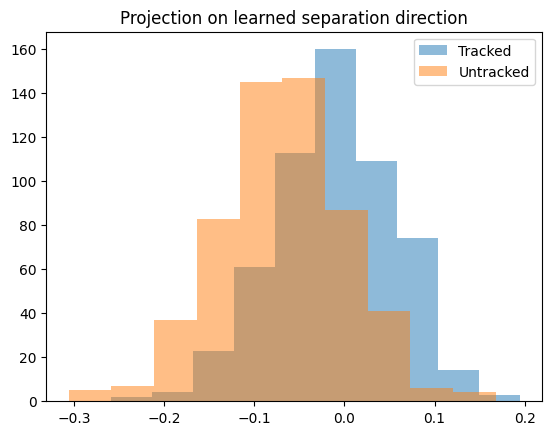

In [204]:
from sklearn.linear_model import LogisticRegression
import numpy as np

X = storyVectors-sentenceVectors
y = (subData['Tracking'] == 'TRACKED').astype(int)

clf = LogisticRegression(max_iter=5000)
clf.fit(X, y)

direction = clf.coef_[0]   # <- to jest Twój kierunek różnicy
direction = direction / np.linalg.norm(direction)
projection = X @ direction


import matplotlib.pyplot as plt

plt.hist(projection[y==1], alpha=0.5, label='Tracked')
plt.hist(projection[y==0], alpha=0.5, label='Untracked')
plt.legend()
plt.title("Projection on learned separation direction")
plt.show()

In [212]:
subData

,Subject,Fragment,Attention,Tracking,Embeddings,UMAP_1,UMAP_2
0,ADNA2507,recall_JANEK_1,1,TRACKED,"[-0.0816406, 0.5704303]",-0.081641,0.570430
1,ADNA2507,recall_JANEK_10,1,TRACKED,"[-0.0028283997, 0.475116]",-0.002828,0.475116
2,ADNA2507,recall_JANEK_11,1,TRACKED,"[-0.38085666, 0.22155172]",-0.380857,0.221552
3,ADNA2507,recall_JANEK_12,1,TRACKED,"[0.2031908, -0.18538356]",0.203191,-0.185384
4,ADNA2507,recall_JANEK_13,1,TRACKED,"[-0.20715898, 0.47191495]",-0.207159,0.471915
...,...,...,...,...,...,...,...
1120,TYTO1309,recall_KAROLINA_5,1,TRACKED,"[0.39073914, -0.32739767]",0.390739,-0.327398
1121,TYTO1309,recall_KAROLINA_6,2,TRACKED,"[-0.052393913, 0.066842265]",-0.052394,0.066842
1122,TYTO1309,recall_KAROLINA_7,2,TRACKED,"[0.25392875, -0.46844035]",0.253929,-0.468440
1123,TYTO1309,recall_KAROLINA_8,1,TRACKED,"[-0.28554314, 0.31027493]",-0.285543,0.310275


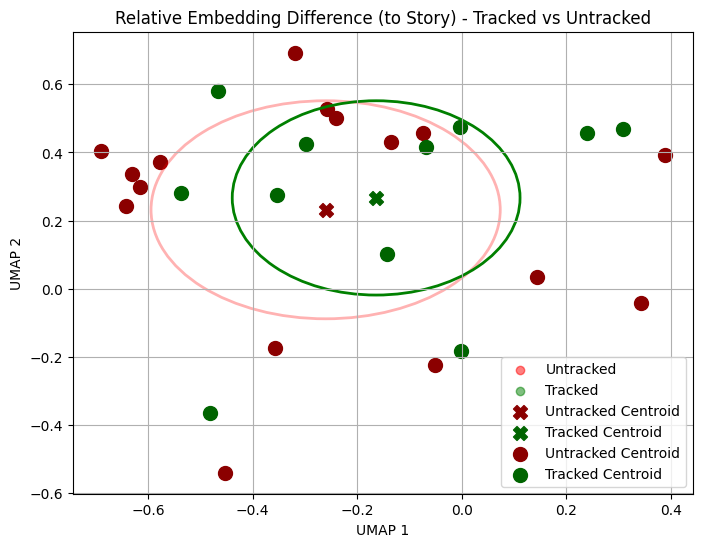

In [215]:
subData2 = subData[subData['Fragment'] =='recall_JANEK_10']

# Punkty wg Tracking
tracked_points = subData2[subData2['Tracking']=='TRACKED'][['UMAP_1','UMAP_2']].to_numpy()
untracked_points = subData2[subData2['Tracking']=='UNTRACKED'][['UMAP_1','UMAP_2']].to_numpy()

# Centroidy
centroid_tracked = tracked_points.mean(axis=0)
centroid_untracked = untracked_points.mean(axis=0)

# Odchylenia
std_tracked = tracked_points.std(axis=0)
std_untracked = untracked_points.std(axis=0)


centroid_tracked_tempPoint = [tracked_points[:,0],tracked_points[:,1]]
centroid_untracked_tempPoint  = [untracked_points[:,0],untracked_points[:,1]]

# Rysowanie
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

plt.figure(figsize=(8,6))

plt.scatter(untracked_points[:,0], untracked_points[:,1], c='red', alpha=0.5, label='Untracked')
plt.scatter(tracked_points[:,0], tracked_points[:,1], c='green', alpha=0.5, label='Tracked')

plt.scatter(*centroid_untracked, c='darkred', s=100, marker='X', label='Untracked Centroid')
plt.scatter(*centroid_tracked, c='darkgreen', s=100, marker='X', label='Tracked Centroid')

plt.scatter(*centroid_untracked_tempPoint, c='darkred', s=100, marker='o', label='Untracked Centroid')
plt.scatter(*centroid_tracked_tempPoint, c='darkgreen', s=100, marker='o', label='Tracked Centroid')


plt.gca().add_patch(Ellipse(centroid_untracked, width=2*std_untracked[0], height=2*std_untracked[1],
                            edgecolor='red', fc='None', lw=2, alpha=0.3))
plt.gca().add_patch(Ellipse(centroid_tracked, width=2*std_tracked[0], height=2*std_tracked[1],
                            edgecolor='green', fc='None', lw=2, alpha=1))
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Relative Embedding Difference (to Story) - Tracked vs Untracked")
plt.legend()
plt.grid(True)
plt.show()


### (5) LLM Surprisal!

LLMs are generally speaking a Prediciton Machine! That generate next word based on what they have learned and vast corpus - maxmimisng the likeliehood of a word!

So! WE can use them o see How distant is the LLM predicted word from a current in a stream!  To do so we use so-called **Perplexity**


#### (5.1) HerBert based Semi- Perplexity 

True Perplexity goes from Autoregresive LLM-s - it is this prediction of a next token. WE can however use a proxy for BERT like language models - so called **pseudo-perplexity**. aT A time we MASK one token ask the model how predicitve it is? And then Sum the Log probabilityes over the position - The lower PPPL is the more expected and predictable current Text is (SO this is a Utterance wise Model!)


PPPL approximates perplexity for masked-language models by masking **one token at a time**, asking the model to predict that token from its context, collecting the log-probability of the **true** token, averaging across all scored positions, and returning

$$
\text{PPPL} = \exp\!\left(-\frac{1}{N}\sum_{i=1}^N \log p_\theta(x_i \mid \text{context with }x_i\text{ masked})\right).
$$

---

##### 1) Tokenize

* We load a **Polish masked-language model**: `allegro/herbert-large-cased` (you can switch to `herbert-base-cased` for speed).
  *This code path is written for BERT-style models; it will also work with RoBERTa models as long as the tokenizer exposes `mask_token_id`, `sep_token_id`, and `sequence_ids`.*
* Tokenization returns two tensors (not embeddings!):

  * `input_ids` → shape **\[1, L]** of integer **token IDs**.
  * `attention_mask` → shape **\[1, L]** of 1/0 flags (1 = real token, 0 = padding).

> The model itself later maps `input_ids` to embeddings internally; you never handle embeddings directly here.


##### 2) Choose which positions to score (`_select_positions`)

* Convert IDs back to **string tokens** and filter:

  * **Skip specials** (`[CLS]`, `[SEP]`, `[PAD]`, `[MASK]`).
  * **Skip pure punctuation** (they’re predictable and add noise).
  * **Score only word starts**: in BERT WordPiece, **continuations** start with `##`; keeping first subwords reduces compute and avoids redundant, trivially predictable suffixes.

The result is a Python list of **token indices** (e.g., `[2, 5, 7, …]`) in the single sequence (hence the `[0]` when reading the lone batch row as `ids[0]`).


##### 3) Build masked variants (vectorized) — core speedup

Inside `_pppl_for_span_fast` (exact path, `group_size=1`):

* Move base tensors to the **same device** as the model:
  `input_ids = input_ids.to(device)`, `attention_mask = attention_mask.to(device)`.
* Let `L = sequence length`, `N = number of positions to score`, `mask_id = tokenizer.mask_token_id`.
* Create **N copies** of the sentence in one go:

  * `masked = input_ids.expand(N, L).clone()` → shape **\[N, L]**.
    Each row is an independent copy we can edit.
* Prepare index tensors on the same device:

  * `rows = [0, 1, …, N−1]`, `cols = tensor(mask_positions)`.
* **Mask one position per row**:

  * `masked[rows, cols] = mask_id` sets the masked column in each row to `[MASK]`.
* Record the **true token IDs** we’re going to score:

  * `target_ids = input_ids[0, cols]` → shape **\[N]**.

> Intuition: row *i* is the original sentence with the token at position `mask_positions[i]` replaced by `[MASK]`.


##### 4) Batch the model & extract log-probs (vectorized gather)

Still in `_pppl_for_span_fast`:

* Iterate through the **N rows** in batches of size `B`:

  * `mb = masked[start:end]` → **\[B, L]**, `attn = attention_mask.expand(B, L)` → **\[B, L]**.
  * Run the model (optionally with **fp16** on GPU):
    `logits = mlm(mb, attention_mask=attn).logits` → **\[B, L, V]**, where `V` is vocab size.
* For this batch, collect logits **at the masked column** for each row:

  * `cols_b = tensor(mask_positions[start:end])` → **\[B]**.
  * `tgt_b  = input_ids[0, cols_b]` → **\[B]** (the **true** token IDs).
  * `pos_logits = logits[0..B-1, cols_b, :]` → **\[B, V]** (vector at the masked site).
  * `log_probs = log_softmax(pos_logits, dim=-1)` → **\[B, V]**.
  * `picked = log_probs.gather(dim=1, index=tgt_b.view(-1,1)).squeeze(1)` → **\[B]**:

    * `log_probs` gives a **log-prob vector over the entire vocab** for each row.
    * `tgt_b` holds the **ground-truth vocab index** per row.
    * `gather` picks **the one log-prob per row** that corresponds to the true token.
      This is $\log p_\theta(x_i\mid\text{masked context})$ for each masked position.
* Accumulate `total_logprob += picked.sum()` and `total_count += picked.numel()`.

> This is fast because we **don’t** build full labels tensors or loop per position—we vectorize both the masking and the “pick the right log-prob” step.


##### 5) Aggregate to PPPL

After all batches:

* Compute the mean log-probability:
  $\text{mean\_logprob} = \frac{\sum \log p(\text{true})}{\#\text{scored tokens}}$.
* Return **PPPL**:
  $\text{PPPL} = \exp\big(-\text{mean\_logprob}\big)$.

> Lower PPPL ⇒ tokens are easier to recover from context (more predictable).
> Higher PPPL ⇒ more “surprising” given the context.


##### 6) Using it for SHPW

Iy Joins Together the Fragment and Utterance BUT MASKS ONLY UTTERANCE... THis is to show the context. The tokenizer builds a single token sequence that contains both parts.
it can use both left and right neighbors in the utterance and the entire fragment (because MLM is bidirectional). So It also places the Context Before and After 
        
        enc = herbertT(fragment, utteranc)
        ids, mask = enc["input_ids"], enc["attention_mask"]

        [CLS]  fragment...  [SEP]  utterance...  [SEP]




In [ ]:
# import math
# import torch
# from transformers import AutoTokenizer, AutoModelForMaskedLM
# from storyTools import PPPL


# ppplPredictor = PPPL(model_name="allegro/herbert-large-cased")

# perplBert  = [] # Perplexity of Bert for a givern Utterance
# perplBertC = [] # Perplexity of Bert contextual on a Fragment
# for i in range(len(dfData)):
#     if VERBOSE:
#         print(f"Processing: {subjList[i]}//{fragmentList[i]}")
#     perplBert.append(ppplPredictor.pppl(dfData['Utterance'].iloc[i], batch_size=256))
#     perplBertC.append(ppplPredictor.pppl_conditioned(dfData['StoryFrag'].iloc[i],dfData['Utterance'].iloc[i], batch_size=256))
#     torch.cuda.empty_cache()


# dfAnalysis['perpBert']  = perplBert
# dfAnalysis['perpBertC'] = perplBertC



#### (5.2) GLM Based Perplexity


This is a proper Perplexity- surprisal, as GLM models are attuned to be used for Perplexity measures 
    

WE use *ppl* function to compute a **standard causal perplexity** -so how well the model predicts next token given all previous tokens: the lower it is the more predictible it is

First we Tokenize our text with the use of tok2 and Special Tokens. WE simialrily as before, use "attention_mask" and gather Tensor IDs for inpouta nd masks, then, we deal with the sequnce length , checking and outocasting 

        # Encode once on CPU (fast tokenizer), then move tensors when needed
        enc = tok2(text, return_tensors="pt", add_special_tokens=True)
        input_ids = enc["input_ids"].to(device)
        attn_mask = enc["attention_mask"].to(device)

then, we set up te stride- because we will compute perplexity in a SLIDING Window Fashion  - i.e. 256 tokens Per Step. It allows us to make a very long texts conteoll  and how many tokens we will encompass. fOR EACH STEP WE OF COURSE  COMPUTE THE BEGINNING AND END LOCATION AND CUT OUR iNPUT_IDS into windows Accordingly!

        if stride is None:
            stride = min(256, model_max // 2)  # conservative default

        input_ids_window = input_ids[:, begin_loc:end_loc]
        attn_window      = attn_mask[:, begin_loc:end_loc]
        labels_window    = input_ids_window.clone()


Now, we make our PASS: in inference mode() we AUTOCAST and then compute basedon input output on our lm2 with our attention_mask and labels in a current step 


        with torch.inference_mode():
            with torch.autocast(device_type=device, dtype=torch.float16, enabled=(fp16 and device == "cuda")):
                out = lm2(input_ids=input_ids_window,
                          attention_mask=attn_window,
                          labels=labels_window)


after that we sum the Loss that was and multiply it by Masked token numbers. Then we compute perplexity as before as a a Sum dividied by Count and Exponenatiated

Similarily it works for Conditioned Perplexity: BUT For this Model we have a FRAGMENT + SEP + UTTERANCE , We mask out the fragment and Separator so the loss is computed on Our Labels in Utterane.

            full_text = fragment + sep + utterance
            enc_full = tok2(full_text, return_tensors="pt", add_special_tokens=True)
            full_ids = enc_full["input_ids"].to(device)
            full_att = enc_full["attention_mask"].to(device)

WE gthen recalculate Context for ONLY fragment and Separator to have a notio nWHERE does the utterance starert

            # Compute boundary (utterance start) robustly by tokenizing the prefix with the same tokenizer
            # (This is cheap and avoids messing with special-token accounting.)
            pref_ids = tok2(fragment + sep, return_tensors="pt", add_special_tokens=True)["input_ids"][0]
            utt_start = int(pref_ids.size(0))  # position where utterance begins in full_ids[0]

THne we simply use the SAME sliding Window BUT ONLY COUNT it on UTTERANCE TOKENS, as All others are counted as a context 








In [ ]:
import torch, math
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
)

class PPL():
    """
        Better and improved perplexity. It is catered toward XGLM and LLAMA based architectures via AutoModelForCausalLM.
        This function is INTERNALLY coded to habe a 4-bit quantisation of wieghts as well as FP16 precision change for efficient memory use


        Main function ppl() computes based on tokenised inputs and attention masking in a moving window way Perplexity for each token, THEN averaging it according to a scheme:

        

        Args:
        - model_name - model to load to improve computation  (Default XGLM-564M)
        - device - whether cuda computation or not. 
        - max_length - what will be the context size
    """

    def __init__(self,model_name="facebook/xglm-564M",device="cuda",max_length =None):

        ### Choose device whether CUDA is available
        self.device = device or "cuda" if torch.cuda.is_available() else "cpu"
    


        ### 4-bit configuration to reduce Memory use by compressing weights of a model
        self.bnb_cfg = BitsAndBytesConfig(
            load_in_4bit=True, # Loading 4bit com,pression
            bnb_4bit_compute_dtype=torch.float16, # Additionaly vreducing Floating Point to Half Precision
            bnb_4bit_quant_type="nf4", # Normal Float 4 quantizaion of Wieghts 
            bnb_4bit_use_double_quant=True, # Second layer of Quantization 
        )


        ### Tokenizer from model with use_fast to optimise the inclusion
        self.tok2 = AutoTokenizer.from_pretrained(model_name, use_fast=True)
        if self.tok2.pad_token is None and self.tok2.eos_token is not None: # SOme model do not habe Padding : so eos_token wihich is end of sentence is made to a padding token 
            self.tok2.pad_token = self.tok2.eos_token
        #torch_dtype = torch.float16 if self.device == "cuda" else None

        ### load model WITH quantization config:
        self.lm2 = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=self.bnb_cfg,
            low_cpu_mem_usage=True,   # keep this
            # no device_map here
        ).eval()

        if torch.cuda.is_available():
            self.lm2.to("cuda")       # move entire quantized model to GPU

        self.lm2.config.use_cache = False

        self.max_length = max_length

    # ====== (1) Plain perplexity (fast path + long-text sliding window) ======
    def ppl(self,text, max_length=None, *, fp16=True, stride=None):
        """
        Perplexity of a single string.
        - If len(tokens) <= model_max_length (or max_length), we do ONE forward (fast).
        - Else we use an overlapping sliding window ('stride') to cover the whole text exactly.
        Returns: scalar perplexity = exp(mean negative log-likelihood per token).
        """
        # Encode once on CPU (fast tokenizer), then move tensors when needed
        enc = self.tok2(text, return_tensors="pt", add_special_tokens=True)
        input_ids = enc["input_ids"].to(self.device)
        attn_mask = enc["attention_mask"].to(self.device)

        model_max = max_length or getattr(self.lm2.config, "n_positions", self.tok2.model_max_length)

        ### When all my text is fitting in a context window there is no need to slide, so we 
        seq_len = int(input_ids.size(1))
        if seq_len <= model_max:
            with torch.inference_mode(): # Gettinh to Context Manager - automtaically casting operation of reduced floating point to reduce comp time!
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=input_ids, attention_mask=attn_mask, labels=input_ids)
            return float(math.exp(out.loss.item()))

        # ----- Long text: exact sliding-window perplexity (HF-recommended pattern) -----
        # Choose stride if not given: advance e.g. 256 tokens per step
        if stride is None:
            stride = min(256, model_max // 2)  # conservative default

        nll_sum = 0.0
        tok_count = 0

        # We will evaluate in windows of up to 'model_max' and only count the NEW tokens per window
        for i in range(0, seq_len, stride):
            begin_loc = max(i + model_max - stride, 0)
            end_loc   = min(i + model_max, seq_len)
            trg_len   = end_loc - i  # how many new tokens we learn this step

         
            input_ids_window = input_ids[:, begin_loc:end_loc]
            attn_window      = attn_mask[:, begin_loc:end_loc]
            labels_window    = input_ids_window.clone()
            window_len = input_ids_window.size(1)
            trg_len = max(0, min(trg_len, window_len))  # 🩹 fix

            # Mask out the loss on the "context" tokens at the left of the window
            labels_window[:, : (labels_window.size(1) - trg_len)] = -100

            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=input_ids_window,
                            attention_mask=attn_window,
                            labels=labels_window)
            nll_sum  += out.loss.item() * trg_len
            tok_count += trg_len

            if end_loc == seq_len:
                break

        return float(math.exp(nll_sum / max(1, tok_count)))


    # ====== (2) Conditioned perplexity: PPL(utterance | fragment) ======
    def ppl_conditioned(self,fragment, utterance, sep="\n\n", max_length=None, *, fp16=True, stride=None):
        """
        Perplexity of UTTERANCE tokens given FRAGMENT context:
        text = fragment + sep + utterance
        We mask out (set -100) the fragment+sep tokens in labels so only utterance contributes to loss.

        Long-text safe: uses same sliding-window logic when needed.
        """
        # Build the full string once
        full_text = fragment + sep + utterance

        # Tokenize full for the model input
        enc_full = self.tok2(full_text, return_tensors="pt", add_special_tokens=True)
        full_ids = enc_full["input_ids"].to(self.device)
        full_att = enc_full["attention_mask"].to(self.device)

        # Compute boundary (utterance start) robustly by tokenizing the prefix with the same tokenizer
        # (This is cheap and avoids messing with special-token accounting.)
        pref_ids = self.tok2(fragment + sep, return_tensors="pt", add_special_tokens=True)["input_ids"][0]
        utt_start = int(pref_ids.size(0))  # position where utterance begins in full_ids[0]

        model_max = max_length or  self.max_length or getattr(self.lm2.config, "n_positions", self.tok2.model_max_length)
        seq_len = int(full_ids.size(1))

        if seq_len <= model_max:
            labels = full_ids.clone()
            labels[:, :utt_start] = -100  # ignore fragment+sep
            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=full_ids, attention_mask=full_att, labels=labels)
            return float(math.exp(out.loss.item()))

        # ----- Long text: sliding-window, but only count utterance tokens -----
        if stride is None:
            stride = min(256, model_max // 2)

        nll_sum = 0.0
        tok_count = 0

        for i in range(0, seq_len, stride):
            begin_loc = max(i + model_max - stride, 0)
            end_loc   = min(i + model_max, seq_len)
            input_ids_window = full_ids[:, begin_loc:end_loc]
            attn_window      = full_att[:, begin_loc:end_loc]

            # Build labels: everything left of utterance start OR left context within the window is -100
            labels_window = input_ids_window.clone()

            # Compute the local index of utterance start within this window
            local_utt_start = max(0, utt_start - begin_loc)

            # Mask:
            # (a) tokens before local_utt_start are fragment/sep -> ignore
            # (b) additionally, ignore the left context part of the window (same as ppl() logic)
            # Determine how many "new" tokens this step contributes:
            trg_len = end_loc - i
            left_ctx = labels_window.size(1) - trg_len

            # Compose a mask: everything < local_utt_start or < left_ctx is ignored
            ignore_upto = max(local_utt_start, left_ctx)
            if ignore_upto > 0:
                labels_window[:, :ignore_upto] = -100

            with torch.inference_mode():
                with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=(fp16 and self.device == "cuda")):
                    out = self.lm2(input_ids=input_ids_window,
                            attention_mask=attn_window,
                            labels=labels_window)

            # Count only tokens actually in the utterance region for this step:
            # count range = [max(i, utt_start), end_loc)
            count_this = max(0, end_loc - max(i, utt_start))
            if count_this > 0:
                nll_sum  += out.loss.item() * count_this
                tok_count += count_this

            if end_loc == seq_len:
                break

        if tok_count == 0:
            return float("nan")
        return float(math.exp(nll_sum / tok_count))



In [ ]:
torch.cuda.is_available()

True

In [ ]:
import math
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
#from storyTools import PPL
import accelerate, transformers, bitsandbytes as bnb
print("accelerate:", accelerate.__version__)
print("transformers:", transformers.__version__)

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype="float16",
)


myPPL = PPL(model_name= "CYFRAGOVPL/Llama-PLLuM-8B-base")


perplBert  = [] # Perplexity of Bert for a givern Utterance
perplBertC = [] # Perplexity of Bert contextual on a Fragment
for i in range(len(dfData)):

    if VERBOSE:
        if len(subjList) !=0:
            print(f"Processing: {subjList[i]}//{fragmentList[i]}")
        else:
            print(f"Processing: {dfData['Subject'].iloc[i]}//{dfData['Fragment'].iloc[i]}")

    perplBert.append(myPPL.ppl(dfData['Utterance'].iloc[i], fp16=True))
    perplBertC.append(myPPL.ppl_conditioned(dfData['StoryFrag'].iloc[i],dfData['Utterance'].iloc[i], fp16=True))
    torch.cuda.empty_cache()
dfAnalysis['perpGLM']  = perplBert
dfAnalysis['perpGLMC'] = perplBertC


perplexity= dfAnalysis.groupby("Attention")[['perpGLM', 'perpGLMC']].agg(['mean','std','min','max']).transpose()
perplexity

accelerate: 1.11.0
transformers: 4.57.1


Fetching 4 files:   0%|          | 0/4 [04:21<?, ?it/s]

KeyboardInterrupt



In [ ]:
dfAnalysis.columns

Index(['Subject', 'Fragment', 'Attention', 'utt_leng', 'Tracked', 'lemmaN',
       'NounsN', 'VerbsN', 'pVerbCount', 'pPronCount', 'LexDiv', 'LexDivS',
       'LexDivSS', 'LemEmbBert', 'LemEmbFtxt', 'TFIDFSim', 'NounEmb',
       'VerbEmb', 'lemmaRuns', 'lemmaRunStds', 'lemmaRunMax', 'lemmaRunMin',
       'lemmaRunMeans', 'Attention2', 'wmd0', 'wmd', 'wmdS', 'Focus',
       'Task-Related Thoughts', 'Mind Wandering', 'Mind Blanking',
       'FragmentSentCosSim', 'FragmentLemmaCosSim', 'FragmentSentCosSimw2v',
       'FragmentLemmaCosSimw2v', 'FragmentLemmaCosSimTFIDF', 'wmdFragments'],
      dtype='object')

In [ ]:
dfAnalysisNewThing = dfAnalysis[['Subject', 'Fragment', 'Attention','pVerbCount', 'pPronCount', 'lemmaRuns', 'lemmaRunStds', 'lemmaRunMax', 'lemmaRunMin','lemmaRunMeans']]

dfAnalysisNewThing.to_excel(os.path.join(savePathFeatures, "dfAnalysis_LinguisticFeatures.xlsx"), index=False)
dfAnalysisNewThing

,Subject,Fragment,Attention,pVerbCount,pPronCount,lemmaRuns,lemmaRunStds,lemmaRunMax,lemmaRunMin,lemmaRunMeans
0,ADNA2507,recall_JANEK_1,1,0,0,"[0.8861579298973083, 0.6336394548416138, 0.654...",0.144730,0.469463,0.886158,0.694830
1,ADNA2507,recall_JANEK_10,1,1,0,"[0.5748855471611023, 0.4921742379665375, 0.571...",0.123170,0.492174,0.904572,0.672414
2,ADNA2507,recall_JANEK_11,1,1,0,"[0.3918211758136749, 0.3545245826244354, 0.518...",0.138886,0.333104,0.804484,0.503248
3,ADNA2507,recall_JANEK_12,1,1,0,"[0.673240602016449, 0.756621241569519, 0.62874...",0.146361,0.232698,0.756621,0.595059
4,ADNA2507,recall_JANEK_13,1,1,0,"[0.6534704566001892, 0.826668381690979, 0.8078...",0.145303,0.370653,0.826668,0.601576
...,...,...,...,...,...,...,...,...,...,...
1120,TYTO1309,recall_KAROLINA_5,1,0,2,"[0.7906710505485535, 0.7726945877075195, 0.644...",0.076304,0.504907,0.790671,0.657756
1121,TYTO1309,recall_KAROLINA_6,2,3,0,"[0.6423227787017822, 0.6339622139930725, 0.742...",0.101547,0.477822,0.854977,0.675504
1122,TYTO1309,recall_KAROLINA_7,2,3,1,"[0.5928024053573608, 0.646397590637207, 0.7142...",0.080944,0.502505,0.773687,0.649324
1123,TYTO1309,recall_KAROLINA_8,1,2,1,"[0.6537131071090698, 0.629010021686554, 0.5992...",0.142591,0.457585,0.952286,0.686518


In [ ]:


perplexity= dfAnalysis.groupby("Attention")[['perpGLM', 'perpGLMC']].agg(['mean','std','min','max']).transpose()
perplexity

Attention               1          2          3          4
perpGLM  mean   30.696064  16.158003  14.914834  18.897068
         std    56.490590   8.195804   8.702394  17.326663
         min     6.018431   6.519554   5.564243   5.917493
         max   775.439885  60.311660  84.201542  72.738545
perpGLMC mean   13.594996  11.427701  10.688514  11.099726
         std    14.685808   4.606631   4.635574   4.680371
         min     2.112384   4.724308   4.977808   5.107722
         max   219.653900  35.034943  45.596562  21.027106

In [ ]:
import sys, importlib, transformers

print("python exe:", sys.executable)
print("transformers:", transformers.__version__)

spec = importlib.util.find_spec("accelerate")
print("accelerate found by importlib?:", spec is not None)

from transformers.utils import is_accelerate_available
print("transformers says accelerate available?:", is_accelerate_available())

if spec:
    import accelerate
    print("accelerate path:", accelerate.__file__)

python exe: c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Scripts\python.exe
transformers: 4.57.1
accelerate found by importlib?: True
transformers says accelerate available?: True
accelerate path: c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\accelerate\__init__.py


### (6) Semantic Web-Based Analyses: 

#### WordNet Characteristics

WordNet is a Database of CONCEPTS in a given Language: Each Noun,Verb and Adjective and Adverb is grouped into a set of **cognitive synonyms - so called SYNSETS**. Each is expressing a differenc Concepts. 

Each Synstet is linked by the Conceptual/Semantic/Lexical Relations - giving us a NETWORK of interconnected meanings

In Polih Wordnets we have two layers:
1. Lexical Units - Pasrt of Speach + Lemma and Sense
2. Synsets: this is a set of synonumous Lexical Units representing One concepts (Nodes of Our Network)

So, WordNet-s are a Multi-relational Graph, where Nodes are  Concepts and Edges are either:
- Taxonomic - Showing Types of Relations (Hypernym - Hyponym, Holonym. Homonim and so on)
- Relatedness - i.e. antynomy
- Lexical - VErb to Noun
- Membership - to which sysnet it belongs


#### Analyses

This ideas here are based on Semantic Webb: 

Our Goal is to see wehthet the content woirds in this utterance are semantically close to each other


**1. SHortest Path Coherence: Pairwise min sense:**

For Each Pair of lemmas in my uttarance we take a Minimum Shortest Path distance between any og their **synsets** then average across pairs - the Lower the distance is in general, the 


**2. Steiner-tree size**

Steiner tree is basd on Weighted Concpet Graphs with concpet Nodes T. **minimum Steiner Tree** is the smallest-total weoghted Subgraph of G that connects al the nodes in T. This graph can be transitory and it CAN gave Subconcepts - so called **Steiner Nodes** - IF such a node can shorten The Connection 
For a Lemma we compute a One Synset. On that synset we compute so-called **Steiner Tree** 


**3. SImilarity Based in Informational Content:**
Here, we try to ascertain, How Specific a Given Concpet is in a Taxonomy or Corpus: 
We based in on **Frequency** of a given Concept - basingon WOrdnets meaning ALL Hyponyms

$$ IC(c) = -log p(c)$$
The  Rarer the Synsets are - the Higher the IC will be 

There are several Measures of IC - each as a IC Between TWO SYNSETS. it is also contingent on **LCS** - *lowest common subsumer* - meaning a mist specific shared common ancestor:
+ *Resnik*                 - is Information conent ON LCS
+ *Lin*                    - It is WEighted IC(LCS) by IC of Synset One and Synset 2
+ *Jiang-Conrath Distance* - it is a differnce between sum of IC sunsest and 2* Resnik similarity

**4. Making Synset for each Lemma and Compute a Shortest Path-distances between consecutive Suynstes**

#### Creating a WordNet and Explorint The Symsets

We now Load WordNEt and Based on Relations aved there we simply make a DAG based on the relations

WordNet is JUST a Dictionairy of Different Relations between Lemmas and more importantly SYNSETS: There are no Weights Based on Familiarity - that is something that we need  to account for. Some of them have subtypes or being Inter-lingual

In WordNet there are over 350 Relations with oneanother - Most of them, are Subtype of 27 Majors:

**1.  Hiponimia** - Relacja łącząca znaczenie z drugim, ogólniejszym, niż to pierwsze, ale należącym do tej samej części mowy, co ono.

        [automatyczny]  -->  [samoistny, samoczynny]

**2.  Hiperonimia** - Relacja łącząca znaczenie z drugim, szczegółowszym, niż to pierwsze, ale należącym do tej samej części mowy, co ono.

        [grupa]  -->  [administracja]

**3.  Synonimia**



**4.  Fuzzynimia** - Relacja łącząca dwa dowolne znaczenia, mówiąca o tym, że istnieje pomiędzy nimi jakiś (nieokreślony) związek znaczeniowy.

        [autokratycznie]  -->          [autokratyczny]

**5.  Holonimia** - Relacja łącząca rzeczownik, który oznacza całość, z drugim rzeczownikiem, oznaczającym część (porcję, element grupy, miejsce, materiał) tej całości.

        [przedsiębiorczość]  -->  [firma, interes, biznes, business, przedsiębiorstwo]

**6.  Meronimia** - Relacja łączy rzeczownik, który jest częścią (porcją, elementem grupy, miejscem, materiałem) czegoś innego, z drugim rzeczownikiem, oznaczającym całość w stosunku do części.

        [sekretarz]  -->   [administracja]

**7.  Bliskoznaczność** - Wyrazy bliskoznaczne mają takie same relacje synsetów (mogą różnić się jedynie hiponimami), ale różnią się w sposób istotny rejestrem.

        [ajencja]  -->  [agencja, przedstawicielstwo, agenda, agentura, oddział, delegatura, ekspozytura]

**8.  Gradacyjnośc** - Relacja łącząca różne stopnie intensywności tej samej cechy w kolejności, według najbliższych sobie stopni natężenia cechy. Podobnre do nacechowanie 

        [dolinka]  --> [dolina]
        [lichawy, kiepskawy]  gradacyjność  [kiepski, marny, lichy]

Therea also Relations that Join the Lemmas in on itslef:

**1.  Typ** - Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.

        [Orbis]  -->  [firma, interes, biznes, business, przedsiębiorstwo]

**2.  Egzemplarz** - Relacja łącząca wyraz pospolity (daną klasę) i, na niższym poziomie ogółu, nazwę własną (przedstawiciela danej klasy). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiperonimii.

        [kontynent]  egzemplarz             [Ameryka]

**3.  Określnik** - Relacja łącząca przymiotnik z rzeczownikiem, jeśli może on określać byty oznaczane przez ten rzeczownik i większość jego hiponimów. Np. przymiotnikiem "kary" możemy określać różnego rodzaju konie, stąd relacja "kary" --> "koń".

         [pośpieszny, pospieszny]  -->         [autobus]

**4. Wartość Cechy** - Relacja łącząca przymiotniki lub przysłówki z rzeczownikiem, który nazywa jakąś cechę, której stopień jest wyrażony tym przymiotnikiem lub przysłówkiem.

        [równomiernie]  -->  [rytm, rytmika, takt]

**5.  Kauzacja** - Relacja łącząca czasownik, oznaczający (s)powodowanie czegoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym czasownikiem, przymiotnikiem, przysłówkiem lub rzeczownikiem.

        [aktualizować, uaktualniać]  -->  [aktualny]

**5.5 Wytwór** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza wytwór|rezulatat jakiegoś działania, a drugi - to, z czego jest wytworem|rezulatatem. Czasownik wyrażający działanie istnieje, ale pozostaje niewyrażony w tej relacji.

        [alergia, uczulenie, nietolerancja, nadwrażliwość]  -->   [alergen]

**6.  Pochodzenie** - Relacja łącząca rzeczownik z przymiotnikiem jakościowym, oznaczającym pochodzenie danego bytu, lub z drugim rzeczownikiem (oznaczającym miejsce), od którego nie istnieje wyraz pochodny w postaci przymiotnika jakościowego, oznaczającego pochodzenie.

         [demokrata]  -->  [amerykański, jankeski]

**7. Procesywność** - Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.

        [ukończyć, skończyć]  -->  [absolwent, wychowanek]

**8.  Wielokrotność** - Relacja łącząca czasownik, oznaczający czynność lub stan powtarzalne (iteratywność) lub to, że ta czynność lub ten stan mają wiele subiektów lub obiektów (dystrybutywność), z drugim czasownikiem, oznaczającym czynność lub stan jednokrotne lub mające jeden subiekt (obiekt).

        [pochwytać]  wielokrotność  [chwycić, ująć]


**9.  Uprzedniość** - Relacja łącząca czasownik z innym czasownikiem, rzeczownikiem, przymiotnikiem lub przysłówkiem oznaczającymi sytuację lub jej cechę, która mogła wystąpić w ciągu przyczynowo-skutkowym wcześniej, niż sytuacja opisywana przez pierwszy czasownik.

         [odczulać]  -->   [alergia, uczulenie, nietolerancja, nadwrażliwość]

**10. Sposób** -  Relacja łącząca czasownik z przysłówkiem, gdy w parafrazie czasownika jest mowa o sposobie wykonywania czynności lub zachodzeniu stanu i sposób ten jest wyrażany przysłówkowo.

        [oblepić]  sposób                          [szczelnie]

**11. Cecha Definicyjna** - Relacja łącząca rzeczownik z drugim rzeczownikiem, przymiotnikiem lub przysłówkiem, informującym o obowiązkowej cesze, która sprawia, że ktoś jest kimś albo czymś.

         [napierdalanka]  -->  [agresja, agresywność]

**12. Obszar** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza obszar zainteresowań kogoś lub czegoś.

        [alergologia]  -->  [alergia, uczulenie, nietolerancja, nadwrażliwość]

**13. Inchoatywność** - Relacja łącząca czasownik, oznaczający zaczynianie (zaczęcie) się czynności lub stanu, z rzeczownikiem lub innym czasownikiem, nazywającymi sytuację powstałą po tej fazie wstępnej.

         [zyskać]  -->  [mieć]


**14. Subiekt**   - Relacja łącząca rzeczownik i czasownik, opisująca fakt, że istnieje jakiś subiekt (rzeczownik) dla czynności lub zdarzenia (czasownik). Relacja ta może zachodzić w obie strony, jednak najczęściej będzie jednostronna.
      
        [grać, odgrywać]  -->     [aktor]

**15. Obiekt** -  Relacja łącząca rzeczownik i czasownik, opisująca fakt, że istnieje jakiś obiekt (rzeczownik) dla czynności lub zdarzenia (czasownik). Relacja ta może zachodzić w obie strony, jednak najczęściej będzie jednostronna.

        [objeżdżać]  -->     [przeszkoda]

**16. Presupozycja** - Relacja łącząca czasownik z innym czasownikiem, rzeczownikiem, przymiotnikiem lub przysłówkiem oznaczającymi sytuację lub jej cechę, która musiała (koniecznie) wystąpić w ciągu przyczynowo-skutkowym wcześniej, niż sytuacja opisywana przez pierwszy czasownik.

    [przeterminować się]  presupozycja                [aktualny, niezwietrzały]



**17. Okoliczność** - Relacja łącząca czasownik z rzeczownikiem, gdy w parafrazie czasownika pojawia się wyrażenie przyimkowe z udziałem rzeczownika, opisujące okoliczności, w jakich zachodzi sytuacja.

        [werbować, rekrutować]  -->  [wojsko, armia]

**18. Stanowość** - Relacja łącząca czasownik stanowy, oznaczający bycie kimś, czymś, jakimś lub jakoś, z rzeczownikiem, przymiotnikiem lub przysłówkiem, nazywającym lub określającym stan, wyrażony przez ten czasownik.

         [dzielić]  stanowość --> [przeszkoda]

**19. Parametr** - Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza parametr definiowany jako przypisana przedmiotowi lub zjawisku mierzalna cecha fizyczna, najczęściej zdefiniowana w specjalistycznym obszarze wiedzy, opisująca wartość czegoś, sprawiająca, że to coś odróżnia się natężeniem jakiejś cechy od innych, podobnych przedmiotów, a drugi - byt, który jest opisywany za pomocą tak zdefiniowanego parametru.

        [żyzność, urodzajność, plenność, żyzność gleby]  parametr  [gleba, ziemia, grunt, podłoże]

**20. Relacje Walentego** 

    [zaktywizować, uaktywnić, ożywić, wzmóc, zmobilizować, zaktywować]  realcje walentego   [czyn, działanie, uczynek, postępek]



What we did, is we collapse All the other Relations to Those types (With some subtypes) - giving us 65 Classess - each with a different Weight from 0 to 2

This allows us to make a Linguistic Graph of a Whole WordNet Corpus, which then can be used to compiute the 


In [14]:
import plwordnet
import networkx as nx
import os
import numpy as np
import math
from functools import lru_cache
from storyTools import addWeightIds,getParentsOnly, inspectRelationsChildren, showRelationExamples, get_RelationsCountDF

# Load once (XML, .gz, or .xz all fine)
wn = plwordnet.load(os.path.join(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\WordNetPL","plwordnet_4_2.xml") ) # path to your file
print(wn)  # sanity: counts of synsets, relations, etc.  # :contentReference[oaicite:1]{index=1}


Słowosieć
  lexical units: 513410
  synsets: 353585
  relation types: 306
  synset relations: 1477851
  lexical relations: 393137
  emotional annotations: 0
  rich descriptions: 0


In [15]:

def getNodeSympathsIDs(lemma,G):
    """
    Returns list of IDs and Names of Lemma adjacent Synsets
    """

    if len([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']]):
        return ([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']],
            [synpos[0] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']])
    else: #### Look for Words inside Synsets:
        return ([synpos[1]['obj'] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])],
            [synpos[0] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])])
#getNodeSympathsIDs('staranie',G)


In [ ]:


# lemma2syn['źle']

# def computePaths(G,firstSyns,secondSyns):
#     """
#         get shortest path between two Synsets:
#         Returns Ids of Nodes n Path and additionally the lsit of Names of Synsets on a Path
#     """
#     if nx.has_path(G,firstSyns, secondSyns):
#         path = nx.dijkstra_path(G, firstSyns, secondSyns, weight="weight")
#         names = [G.nodes[nd].get('obj', []) for nd in path]

#     else:
#         print(f"     Warning! No Path between {firstSyns} and {secondSyns}" )
#         path = [None]
#         names = [firstSyns,secondSyns]
    
#     return path,names

# computePaths(G,('syn', 452661),('syn',455028))

In [16]:
import pandas as pd

#### Create a Universal DataFrames Containing Synsets to compare:
SynsetTuple = [
    [synset,  [lu.name for lu in  wn.synsets[synset].lexical_units]]
    for synset in wn.synsets  # iterable of Synset objects
]
dfSynsets = pd.DataFrame(SynsetTuple,columns=["firstSynset","NamesFirst"]) # Synset IDs
dfSynsets2 = pd.DataFrame(SynsetTuple,columns=["SecondSynset","NamesSecond"]) # Synset IDs

### DF of Relations Ids and Names (Exteme;ly Important)
dfRelations  = pd.DataFrame([
    vars(rel) for rel in wn.relation_types.values()
])
dfRelations['parent'] = dfRelations[dfRelations['parent'].notna()]['parent'].apply(lambda x: x.name)

#print(dfRelations[(dfRelations['type'] == "relacja pomiędzy synsetami") & (dfRelations['parent'].notna())][['name','description']].reset_index().to_string())
#### List of all Synset Relations
dfSynsetsRelations = pd.DataFrame(np.array(wn.synset_relations),columns=["firstSynset","id","SecondSynset"])


### Joint Togethe Relations, and Synsets for All Corpus Relations together 
dfWN = pd.merge(dfRelations[['name','type','id','parent']],dfSynsetsRelations, on='id')
dfWn = pd.merge(dfSynsets,dfWN,on="firstSynset")
dfWn = pd.merge(dfSynsets2,dfWn,on="SecondSynset")

dfWn = dfWn[['firstSynset',"id",'SecondSynset','NamesFirst','name','NamesSecond','type','parent']]
if VERBOSE:
    dfWn

In [17]:
#### Manually Add Missing Name Sysnets for JANEK and KAROLINA

### === Add Janek === ###
### Add to Synset List:
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Janek"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

#### Add to dfWn List:
new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':54,"SecondSynset":400041, "NamesFirst": ["Janek"], "name": "nacechowanie","NamesSecond": ["Jan"],"type": "relacja leksykalna","parent":"nacechowanie","description":'Relacja łącząca rzeczowniki nacechowane stylistycznie (zdrobnienia, zgrubienia i inne ekspresywy, oraz nazwy istot młodych) z rzeczownikami, które są ich podstawami słowotwórczymi.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

### === Add Karolina === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Karolina"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	106	,"SecondSynset": 225273	,"NamesFirst": ["Karolina"]	, "name":  "typ","NamesSecond": ["człowiek płci żeńskiej"]	,"type": "relacja pomiędzy synsetami"	,"parent":"NaN", "description": 	'Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

### === Add Magda === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["Magda"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	106	,"SecondSynset": 225273	,"NamesFirst": ["Magda"]	, "name":  "typ","NamesSecond": ["człowiek płci żeńskiej"]	,"type": "relacja pomiędzy synsetami"	,"parent":"NaN", "description": 	'Relacja łącząca nazwę własną (przedstawiciela danej klasy) i, na wyższym poziomie ogółu, wyraz pospolity (daną klasę). Stosowana tylko dla rzeczowników, jest odpowiednikiem hiponimii.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

# ### === Add Wyobrazić === ###
# newSynsID = dfSynsets['firstSynset'].max()+1
# new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["wyobrazić"]]})
# dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

# new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	86	,"SecondSynset": 8228	,"NamesFirst": ["wyobrazić"]	, "name":  "typ","NamesSecond":  ['wyobrażenie']	,"type": "procesywność"	,"parent":"NaN", "description": 	'Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.'})
# dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

# new_row2 = pd.DataFrame({"firstSynset": 8228, 'id':	3436	,"SecondSynset": 3978	,"NamesFirst": ["wyobrażenie"]	, "name":  "typ","NamesSecond":  ['wyobraźnia']	,"type": "wytwór|rezultat_przy_niewyrażonym_predykacie"	,"parent":"NaN", "description": 	'Relacja łącząca dwa rzeczowniki, spośród których jeden oznacza wytwór|rezulatat jakiegoś działania, a drugi - to, z czego jest wytworem|rezulatatem. Czasownik wyrażający działanie istnieje, ale pozostaje niewyrażony w tej relacji.'})
# dfWn = pd.concat([dfWn, new_row2], ignore_index=True)

# ### === Add Wyobrażać === ###
# newSynsID = dfSynsets['firstSynset'].max()+1
# new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["wyobrażać"]]})
# dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

# new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	60	,"SecondSynset": newSynsID-1	,"NamesFirst": ["wyobrażać"]	, "name":  "typ","NamesSecond":  ['wyobrazić']	,"type": "bliskoznaczność"	,"parent":"NaN", "description": 	'bliskoznaczność'})
# dfWn = pd.concat([dfWn, new_row2], ignore_index=True)


# ### === Add Wydarzyć === ###
# newSynsID = dfSynsets['firstSynset'].max()+1
# new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["wydarzyć"]]})
# dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

# new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	86	,"SecondSynset": 8228	,"NamesFirst": ["wydarzyć"]	, "name":  "typ","NamesSecond": ['wydarzenie']	,"type": "procesywność"	,"parent":"NaN", "description": 	'Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.'})
# dfWn = pd.concat([dfWn, new_row2], ignore_index=True)


### === Add Myśli === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["myśli"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	60	,"SecondSynset": 2869	,"NamesFirst": ["myśli"]	, "name":  "typ","NamesSecond": ['myśl']	,"type": "bliskoznaczność"	,"parent":"NaN", "description": 	'bliskoznaczność'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)




### === Add starać === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["starać"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	86	,"SecondSynset": 399009	,"NamesFirst": ["starać"]	, "name":  "typ","NamesSecond": ['staranie']	,"type": "procesywność"	,"parent":"NaN", "description": 	'Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)




### === Add Marzenia === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["marzenia"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	108	,"SecondSynset": 5134	,"NamesFirst": ["marzenia"]	, "name":  "typ","NamesSecond": ['marzenie']	,"type": "fuzzy"	,"parent":"NaN", "description": 	'fuzzynimia_synsetów'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)



# ### === Add Wizualizacja === ###
newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["wizualizować"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	86	,"SecondSynset": 7071234	,"NamesFirst": ["wizualizować"]	, "name":  "typ","NamesSecond": ['wizualizacja']	,"type": "procesywność"	,"parent":"NaN", "description": 	'Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)


newSynsID = dfSynsets['firstSynset'].max()+1
new_row = pd.DataFrame({"firstSynset": newSynsID, "NamesFirst": [["zwizualizować"]]})
dfSynsets = pd.concat([dfSynsets, new_row], ignore_index=True)

new_row2 = pd.DataFrame({"firstSynset": newSynsID, 'id':	86	,"SecondSynset": 7071234	,"NamesFirst": ["zwizualizować"]	, "name":  "typ","NamesSecond": ['wizualizacja']	,"type": "procesywność"	,"parent":"NaN", "description": 	'Relacja łącząca czasownik, oznaczający sta(wa)nie się czymś, kimś, jakimś lub jakoś, ze skutkiem sytuacji, nazwanej przez ten czasownik, wyrażonym innym przymiotnikiem, przysłówkiem lub rzeczownikiem.'})
dfWn = pd.concat([dfWn, new_row2], ignore_index=True)



In [ ]:

# def getNodeSympathsIDs(lemma,G):
#     """
#     Returns list of IDs and Names of Lemma adjacent Synsets
#     """

#     if len([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']]):
#         return ([synpos[1]['obj'] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']],
#             [synpos[0] for synpos in G.nodes.items()  if lemma in synpos[1]['obj']])
#     else: #### Look for Words inside Synsets:
#         return ([synpos[1]['obj'] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])],
#             [synpos[0] for synpos in G.nodes.items()  if len([True for word in synpos[1]['obj'] if lemma in word.split(" ")])])
# getNodeSympathsIDs('rozproszyć',G)


In [18]:

### Changing the Name for Parent's Name as well as Changing IDs To Proper ones
dfWnC =  getParentsOnly(dfWn,dfRelations)


In [19]:

### Create a DataFrame containing All Good Relations that are subjected to Weightening 
dfWnCount = get_RelationsCountDF(dfWnC,dfRelations)
dfWnCount.to_excel(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\SecondExp\RecallAnalysis\GoodRelations.xlsx")
if VERBOSE:
    dfWnCount

In [20]:

#### Create a Weight DataFrame
dd = pd.read_excel(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\SecondExp\RecallAnalysis\Weights_calibrated.xlsx")
dfWeights = pd.merge(dfWnCount[['id','RelationName']],dd[['id','Weight_Calibrated']],on='id')
dfWeights.rename(columns={'Weight_Calibrated' : 'Weight'},inplace=True)
if VERBOSE:
    dfWeights

In [21]:
#### Inspect Relation Examples from Corpus


def showRelationExamples(dfWn, relList = None,N=3):
    """
        Prints N examples of a given Relation from a current Named Dataset or a List provided
    """

    if relList is None:
        relList = list(dfWn['name'].unique())

    for i,rel in enumerate(relList):
        print(f"\n\n ==== Current Relation: {rel} ==== N: {len(dfWn[dfWn['name']==rel][['NamesFirst','name','NamesSecond']])} \n")
        if len(dfWn[dfWn['name']==rel][['NamesFirst','name','NamesSecond']]) >= N:
            print(dfWn[dfWn['name']==rel][['NamesFirst','name','NamesSecond']].sample(n=N).to_string())
        else:
            print(dfWn[dfWn['name']==rel][['NamesFirst','name','NamesSecond']].sample(n=len(dfWn[dfWn['name']==rel][['NamesFirst','name','NamesSecond']])).to_string())


if VERBOSE:
    showRelationExamples(dfWn,relList=list(set(dfWnC['name'].unique()).difference(list(dfWeights['RelationName']))))



 ==== Current Relation: Also see ==== N: 2697 

          NamesFirst      name      NamesSecond
628188   [righteous]  Also see           [just]
625778  [unpeaceful]  Also see        [hostile]
617520  [uninformed]  Also see  [unenlightened]


 ==== Current Relation: Domain_of_synset_-_REGION ==== N: 1352 

                                                                                                       NamesFirst                       name                                   NamesSecond
951857                                                                                  [France, French Republic]  Domain_of_synset_-_REGION                                  [prefecture]
932725                                                                                  [France, French Republic]  Domain_of_synset_-_REGION  [National Liberation Front of Corsica, FLNC]
1078627  [United Kingdom, UK, U.K., Britain, United Kingdom of Great Britain and Northern Ireland, Great Britain]  Domain_of_synse

In [22]:

#### Get a Graph Weightsd Based on xlsx Mapping!

import networkx as nx
import pickle 
dfRelationsW = dfWeights
dfWn = dfWnC
from storyTools import ownGraphMaking,GetUtteranceWeights





def ownGraphMaking(dfWn,dfRelationsW,dfSynsets):

    """
        This is Home-brewed function that aims at making a graph of Nodes Based on my own DFs.
        Synsets are Always Characterised by Word List - Nothing More - nothing Less! 

        We Iterate over positions in dfWn, giving us all relations that has been happening 
    """

    G = nx.Graph()
    omitted = 0
    DEFAULT_WEIGHT = 0.5
    ### 1. Creating A Nodes List
    for i in range(len(dfSynsets)):

        ### Adding Node
        G.add_node(("syn", dfSynsets['firstSynset'].iloc[i]), obj=dfSynsets['NamesFirst'].iloc[i])

    ### 2. Add Synsets Relations:

    for i in range(len(dfWn)):

        

        if not len(dfRelationsW[dfRelationsW['id'] == dfWn['id'].iloc[i]]['Weight']):
            omitted +=1
            #print(f" on {i}/{dfWn['name'].iloc[i]} there are no Weights: - Probably an English Word: AddingDefault ")
            #currWeight = DEFAULT_WEIGHT
            continue  # ← CHANGED: SKIP when weight is missing (no default)

        else:
            currWeight = dfRelationsW[dfRelationsW['id'] == dfWn['id'].iloc[i]]['Weight'].iloc[0]

        u, v = ("syn", dfWn['firstSynset'].iloc[i]), ("syn", dfWn['SecondSynset'].iloc[i])
        if G.has_edge(u, v):
            G[u][v]["weight"] = min(G[u][v]["weight"], currWeight)
        else:
            G.add_edge(u, v, weight=currWeight)

    print(f"Omitted Values {omitted}")
    return G

if os.path.isfile(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\SecondExp\RecallAnalysis\Graph.pkl"):
    G = pickle.load(open(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\SecondExp\RecallAnalysis\Graph.pkl",'rb'))
else:

    G = ownGraphMaking(dfWnC,dfWeights,dfSynsets)
    with open(r"C:\Users\barak\Documents\GitHub\startegicMW_lite\Experiment\analysis\SecondExp\recallAnalysis\Graph.pkl", 'wb') as file:
        pickle.dump(G, file)

In [23]:
from networkx.algorithms.approximation import steiner_tree
from collections import defaultdict

##### --- Functions for Graph Computations ----- #####
def getNodeSympathsIDs_fuzzy(lemma, idx, id2obj, k=25):
    nids = nids[:k]  # twardy limit
    return ([id2obj[n] for n in nids], nids)

def build_fuzzy_index(G,k=25):
    """
        Returnd lemma --> synset dictionairy WITH synsets that contain lemma as a substring
    """
    idx, id2obj = defaultdict(list), {}
    for nid, data in G.nodes(data=True):
        names = data.get('obj', []) or []
        id2obj[nid] = names
        for name in names:
            s = name
            for i,key in enumerate(set(s.split() + [s])):  # tokeny + cała fraza
                if (not idx[key] or idx[key][-1] != nid) and i <=k:  # deduplikacja w locie
                    idx[key].append(nid)
    return dict(idx), id2obj

def build_lemma_index(G):
    """
    Build lemma -> list[synset_id] once. Expects node['obj'] to be list of lemmas.
    """
    idx = {}
    iddata = {}
    for nid, data in G.nodes(data=True):
        for lemma in data.get('obj', []):
            idx.setdefault(lemma, []).append(nid)
            iddata.setdefault(nid,[]).append(data)
    return idx,iddata

def induce_khop_subgraph(G, seeds, k=2):
    """
    Induce a subgraph containing nodes within k hops (unweighted hop count) of seeds.
    Greatly reduces Dijkstra’s search space.
    """
    visited = set(seeds)
    frontier = set(seeds)
    for _ in range(k):
        nbrs = set()
        for u in frontier:
            nbrs.update(G.predecessors(u) if G.is_directed() else G.neighbors(u))
            if G.is_directed():
                nbrs.update(G.successors(u))
        frontier = nbrs - visited
        visited |= frontier
    return G.subgraph(visited).copy()

def average_similarity_from_context(dist_map, candidates):
    """
    Convert distances to mean similarity for each candidate.
    dist_map: dict[node -> distance] returned by multi-source Dijkstra
    """
    scores = {}
    for c in candidates:
        d = dist_map.get(c, None)
        # multi-source dijkstra gives the best (min) distance from any context node
        # We can use 1/(1+d) as similarity; if you want an average over all context nodes,
        # switch to single-source for each context, but that defeats the purpose.
        if d is None:
            scores[c] = 0.0
        else:
            scores[c] = 1.0 / (1.0 + d)
    return scores

def disambiguate_lemma_fast(lemma, ctx_lemmas, lemma2syn, G,
                            window=2, khop=2, use_subgraph=True):
    """
    Fast, corpus-free WSD:
    - collect candidate synsets for target lemma
    - collect candidate synsets for context window
    - (optional) induce small k-hop subgraph around seeds
    - run ONE multi-source Dijkstra from all context synsets
    - score each candidate by 1/(1+dist)
    """
    # candidates for the target lemma
    candidates = lemma2syn.get(lemma, [])
    if not candidates:
        return None, {}



    # context synsets (union)
    context_syns = set()
    for w in ctx_lemmas:
        context_syns.update(lemma2syn.get(w, []))
    if not context_syns:
        # no context evidence; default to first or any prior you may keep
        return candidates[0], {c: 0.0 for c in candidates}

    # optionally work on a tiny induced subgraph to speed up Dijkstra
    Guse = G
    if use_subgraph:
        seeds = set(candidates) | set(context_syns)
        Guse = induce_khop_subgraph(G, seeds, k=khop)

    # multi-source Dijkstra once per lemma
    # NOTE: weights must be "costs" (lower=closer)
    dist = nx.multi_source_dijkstra_path_length(Guse, context_syns, weight='weight')

    scores = average_similarity_from_context(dist, candidates)
    best = max(scores, key=scores.get)
    return best, scores


lemma2syn,lemma2synwords = build_lemma_index(G)
lemma2synFuzz,lemma2synwordsFuzz = build_fuzzy_index(G)

def context_window(seq, center, left=3, right=3):
    """
    Return context lemmas around `center` index, clamped to edges,
    excluding the center token itself.
    """
    n = len(seq)
    i = center
    L = max(0, i - left)
    R = min(n, i + right + 1)
    # exclude center
    return seq[L:i] + seq[i+1:R]

def pair_contexts(seq, i, left=2, right=2):
    """
    For adjacent pair (i, i+1), return two contexts:
      - ctx_first: context for seq[i]
      - ctx_second: context for seq[i+1]
    Each uses the same (left,right) windowing, clamped to edges,
    and excludes its own center token.
    """
    j = i + 1
    ctx_first  = context_window(seq, i, left, right)
    ctx_second = context_window(seq, j, left, right)
    return ctx_first, ctx_second
#### Compute Every Path Variation between conjoined Synsets 


def computePaths(G,firstSyns,secondSyns,weightParams='weight'):
    """
        get shortest path between two Synsets:
        Returns Ids of Nodes n Path and additionally the lsit of Names of Synsets on a Path
    """

    
    if nx.has_path(G,firstSyns, secondSyns):
        path = nx.shortest_path(G, firstSyns, secondSyns, weight=weightParams)
        names = [G.nodes[nd].get('obj', []) for nd in path]

    else:
        print(f"     Warning! No Path between {firstSyns} and {secondSyns}" )
        path = [None]
        names = [firstSyns,secondSyns]
    
    return path,names


def computePathWeights(path,G,avg1, use_weights=True):
    """
        Returns computed weights in a Path Both as list and a single Number: 
    """

    if not path or path == [None]:
        return float('nan'), []  # <- ZWRACA NAN zamiast 0!

    if not use_weights:
        # koszt = liczba hopów
        return len(path) - 1, [1] * (len(path) - 1)
    allWeights = []
    for i in range(len(path)-1):
        allWeights.append(G.edges[path[i],path[i+1]]['weight'])
    if avg1:
        avgNum = len(allWeights)
        hopP = 0.05 * (len(allWeights) - 1) # N.Hops Penalty - 

    else:
        avgNum = 1;
        hopP = 0
    return sum(allWeights)/avgNum +hopP,allWeights




def GetUtteranceWeights(G,lemmas,lemma2syn,avg1=False,mode="minAggrPath",use_weights = True):
    """
        gets Weight for Every Concept transition in an Utterance.
        Computes Shortest Path in our Semantic Graph G: Computing it for every possible Synset combination between two lemmas

        Returns - Dictionairy of all path specific
                - DataFrame   of Weights for every subsequent Concept Pairs with Paths and OnPath Synsets
    """

    minimNames = []
    minimPath = []
    minimWeights = []
    pathsDict = {}
    outOfPlaceLemmas = []
    pathLengths = []

    weight_param = "weight" if use_weights else None


    ### ==LEMMA SELECTION: Selecting ONLY lemmas that are in a given Synset + Printing Absent Lemmas: 
    wrongLems = []
    for lem in lemmas:
        try:
            lemma2syn[lem]
        except KeyError:
            print(f"    Word not in semantic graph: | {lem} ")
            wrongLems.append(lem)
    filtered = [x for x in lemmas if x not in wrongLems]


    ### === Word Sense Disambiguation: 

    choice = []
    for i in range(len(filtered)):
        ctx_first  = context_window(filtered, i, left=3, right=3)
        chosen,names = disambiguate_lemma_fast(filtered[i], ctx_first, lemma2syn,G, window=2)
        if chosen is None:
            print("Warning!   This Lemma Dict has NO Synsets for that word")
        choice.append(chosen)


   #### ====== Minimal Aggregated Path ====== #####
    if mode == "minAggrPath": # default 0 
        for i in range(len(filtered)-1):

            syn1 = choice[i]
            syn2 = choice[i+1]

            # Get better search with this Dictionairy:
            pair_key = f"{filtered[i]}-{filtered[i+1]}"

            path_ids, path_names = computePaths(G, syn1, syn2, weight_param) # Getr Paths
            w, _ = computePathWeights(path_ids, G, avg1, use_weights)        # GEt Weights 

            # Detailed Path for Diagnosis
            pathsDict[pair_key] = pd.DataFrame({
                "PathIds": [path_ids],
                "Synsets": [path_names],
                "Weights": [w]
            })

            minimWeights.append(w)
            minimPath.append(path_ids)
            minimNames.append(path_names)
            pathLengths.append(len(path_ids))

        return pd.DataFrame([filtered[:-1],filtered[1:],minimWeights,minimPath,minimNames,pathLengths],index = ['firstEnt','secondEnt','Weights','Path','Synsets','Length']).transpose(),pathsDict,wrongLems

    #### ====== Mode for Steiner Trees ======= ####
    elif mode == "steiner":


        ### Compute Steiner tree on Disambiguate Synstes
        S = steiner_tree(G, choice, weight=weight_param)

        ### Get Weights or Number of Edges from Steiner as a proxy for MINIMAL TREE as well as the whole tree
        if use_weights:
            total_weight = sum(nx.get_edge_attributes(S, 'weight').values())
        else:
            total_weight = S.number_of_edges()

        ### Returns a dictionairy containing a Weight, Number of Nodes and Edges, as well as whole Tree and Dictionairy of Paths as well as Lemmas not contained in WordNet: 
        return {'Steiner Weight' : total_weight, 'N': len(S.nodes()),'Nodes':list(S.nodes()), "EdgeNumber" : S.number_of_edges(),'SteinerTree' : S},pathsDict,wrongLems
    



allPairWeights,_,_ = GetUtteranceWeights(G,dfData['Lemmas'].iloc[15],lemma2synFuzz)  # Get Seed DF


     Warning! No Path between ('syn', 7088820) and ('syn', 7088821)
     Warning! No Path between ('syn', 7088821) and ('syn', 628)


In [24]:

G_clean = G.copy()
isolates = list(nx.isolates(G_clean))  # <- zamiana na listę!
G_clean.remove_nodes_from(isolates)



# 2. Upewnij się, że terminale są w największym spójnym komponencie
largest_cc = max(nx.connected_components(G_clean), key=len)
G_largest = G_clean.subgraph(largest_cc).copy()


lemma2syn_clean = {
    lemma: [syn for syn in syns if syn in G_largest]
    for lemma, syns in lemma2synFuzz.items()
    if any(syn in G_largest for syn in syns)  # <-- tylko jeśli istnieje przynajmniej 1 synset
}


### Get the statistics for Remvoed Observations: 


print("========= WodNet vs Minimal Coherent Wordnet ========\n")
print("              WordNet     Coherent")
print(f"Nodes:      { G.number_of_nodes()}          { G_largest.number_of_nodes()}")
print(f"NoIsolates: { G.number_of_nodes()-len(isolates)}          { G_largest.number_of_nodes() }")
print(f"Edges:      { G.number_of_edges()}          { G_largest.number_of_edges()}\n")
print(f"DictLen:    {len(lemma2synFuzz)}          {len(lemma2syn_clean)}")
print(f"DictLenIso: {len(lemma2synFuzz)}          {len(lemma2syn_clean)}")

print(f"Percentage of True Missing Nodes:  {100*(G.number_of_nodes()-len(isolates)-G_largest.number_of_nodes())/(G.number_of_nodes()):2.2f}%")




========= WodNet vs Minimal Coherent Wordnet ========

              WordNet     Coherent
Nodes:      353593          330993
NoIsolates: 332629          330993
Edges:      626875          625987

DictLen:    386997          372594
DictLenIso: 386997          372594
Percentage of True Missing Nodes:  0.46%


In [25]:

allPairWeights,_,_ = GetUtteranceWeights(G_largest,dfData['Lemmas'].iloc[15],lemma2syn_clean,mode="steiner")  # Get Seed DF

    Word not in semantic graph: | Karolina 


In [ ]:
#### Get all Utterances Paths: 
AVG  = True
missedLemmas = []
weightedPaths = []
missedLemmasSteiner = []

anType = 'minAggrPath'; # Gow We Compute Paths:
import time
allPairWeights,_,_ = GetUtteranceWeights(G,dfData['Lemmas'].iloc[0],lemma2synFuzz,mode='minAggrPath')  # Get Seed DF
allPairWeights['UttID'] = -1


tempSteiner,_,_ = GetUtteranceWeights(G_largest,dfData['Lemmas'].iloc[0],lemma2syn_clean,mode='steiner')  # Get Seed DF
allSteiner = pd.DataFrame([i,tempSteiner['Steiner Weight'],tempSteiner['N'],tempSteiner['EdgeNumber']],index=['UttID','Weight','NodeN','EdgeN']).transpose()

for i in range(len(dfData)):

    if VERBOSE:
        print(f"Current Processing {i}: {dfData['Subject'].iloc[i]} | {dfData['Fragment'].iloc[i]}")


    # t = time.time()
    
    #### ==== Minimal Viabl Tree  ====
    tempSteiner,_,outOfPlaceLemmasSteiner = GetUtteranceWeights(G_largest,dfData['Lemmas'].iloc[i],lemma2syn_clean,mode="steiner")  # Get Seed DF

    #### ==== Minimal Aggregated Path==== ####
    tempDf,_,outOfPlaceLemmas = GetUtteranceWeights(G,dfData['Lemmas'].iloc[i],lemma2synFuzz,mode='minAggrPath')  # Get Seed DF

    # elapsed = time.time() - t
    # print(elapsed)

    tempDf['UttID'] = i
    allPairWeights = pd.concat([allPairWeights,tempDf], ignore_index=True)
    allSteiner =  pd.concat([allSteiner ,pd.DataFrame([i,tempSteiner['Steiner Weight'],tempSteiner['N'],tempSteiner['EdgeNumber']],index=['UttID','Weight','NodeN','EdgeN']).transpose()], ignore_index=True)
    
    missedLemmas = missedLemmas+outOfPlaceLemmas
    missedLemmasSteiner = missedLemmasSteiner + outOfPlaceLemmasSteiner
    ##### ==== Minimal Viable Tree - Path ===== #####

    if VERBOSE:
        if tempDf['Weights'].sum() == 0:
            print(f"\n    No Weights: Meaning that no meaningfull lemmas were found in this Utterance")
        print(f"       Current Weights:         {tempDf['Weights'].sum():4.1f}")
        print(f"       Current Weights Steiner: {tempSteiner['Steiner Weight']:4.1f}")
        print(f"       Current Edge:            {tempDf['Length'].sum():4.1f}")
        print(f"       Current Stein Edge/Node: {tempSteiner['N']}/{tempSteiner['EdgeNumber']:4.1f}")


### Get a Distribution to know the Weight of a Missing Values
WeightDist = allPairWeights[~allPairWeights['Weights'].isna()]['Weights'];
allPairWeights[allPairWeights['Weights'].isna()] = np.mean(WeightDist) + 2*np.std(WeightDist); # Fill missing values

### Get our propoer Computational Counts
WeightDist2 =allPairWeights[['Weights','Length','UttID']].groupby('UttID').agg(['sum','count'])[['Weights','Length']];
WeightDist2['count'][WeightDist2['count'] == 0] = 1


allSteiner = allSteiner[1:]
allSteiner.reset_index(drop=True, inplace=True)

### minAggrPath
dfAnalysis['WordNet_minAggrPath_Length'] = WeightDist2['Length']['sum']
dfAnalysis['WordNet_minAggrPath_Weight'] = WeightDist2['Weight']['sum']
dfAnalysis['WordNet_minAggrPath_WeightAvg'] = WeightDist2['Weight']['sum']/WeightDist2['Length']['count']
dfAnalysis['WordNet_minAggrPath_LengthAvg'] = WeightDist2['Length']['sum']/WeightDist2['Length']['count']

### Steiner's
dfAnalysis['WordNet_Steiner_EdgeN'] = allSteiner['EdgeN']
dfAnalysis['WordNet_Steiner_NodeN'] = allSteiner['NodeN']
dfAnalysis['WordNet_Steiner_Weight'] = allSteiner['Weight']
dfAnalysis['WordNet_Steiner_WeightAvg'] = allSteiner['Weight']/ WeightDist2['Length']['count']
dfAnalysis['WordNet_Steiner_EdgeNAvg'] = allSteiner['EdgeN'] / WeightDist2['Length']['count']
dfAnalysis['WordNet_Steiner_NodeNAvg'] = allSteiner['NodeN']/ WeightDist2['Length']['count']


### Get single Utterance Weighs

print(f"Missed Lemma's Number:           {len(missedLemmas)/np.sum([ len(i) for i in all_Lemas])}")
print(f"Missed Lemma's Number (Steiner): {len(missedLemmasSteiner)/np.sum([ len(i) for i in all_Lemas])}")



wordnetWeights = dfAnalysis.groupby('Attention')[['WordNet_minAggrPath_Weight','WordNet_minAggrPath_WeightAvg','WordNet_minAggrPath_Count','WordNet_Steiner_EdgeN','WordNet_Steiner_NodeN','WordNet_Steiner_Weight','WordNet_Steiner_WeightAvg']].agg(['mean','std','min','max']).transpose()
wordnetWeights

Current Processing 0: ADNA2507 | recall_JANEK_1
       Current Weights:         47.4
       Current Weights Steiner: 35.2
       Current Edge:            105.0
       Current Stein Edge/Node: 68/67.0
Current Processing 1: ADNA2507 | recall_JANEK_10
       Current Weights:         55.6
       Current Weights Steiner: 38.5
       Current Edge:            108.0
       Current Stein Edge/Node: 60/59.0
Current Processing 2: ADNA2507 | recall_JANEK_11
       Current Weights:         35.8
       Current Weights Steiner: 21.9
       Current Edge:            72.0
       Current Stein Edge/Node: 35/34.0
Current Processing 3: ADNA2507 | recall_JANEK_12
    Word not in semantic graph: | wchodzący 
    Word not in semantic graph: | wchodzący 
       Current Weights:         56.7
       Current Weights Steiner: 37.1
       Current Edge:            142.0
       Current Stein Edge/Node: 80/79.0
Current Processing 4: ADNA2507 | recall_JANEK_13
       Current Weights:         54.1
       Current Weights

Attention                                   1          2          3          4
WordNet_minAggrPath_Weight    mean   45.07363  67.276854   69.03326  57.996154
                              std   24.679837  30.674228  34.116412  39.861946
                              min         1.3      10.35        5.1        8.8
                              max       131.0      192.2     179.75      117.3
WordNet_minAggrPath_WeightAvg mean   4.553593   4.579004   4.526217   4.729012
                              std    0.687111   0.536296   0.626163   0.622559
                              min         1.3   2.583333        2.3   3.792857
                              max        6.65       6.02   6.394444   5.783333
WordNet_minAggrPath_Count     mean   9.817352   14.58427  15.096916  12.307692
                              std    5.262315   6.254744   7.113451    8.16889
                              min         1.0        3.0        2.0        2.0
                              max        35.0       37.0       38.0       24.0
WordNet_Steiner_EdgeN         mean  49.538813  56.838565  54.916667  41.230769
                              std   22.065891  23.716887  24.277708  24.856769
                              min         5.0        0.0        0.0        3.0
                              max       123.0      126.0      149.0       82.0
WordNet_Steiner_NodeN         mean  50.538813  57.836323  55.912281  42.230769
                              std   22.065891  23.722319  24.287761  24.856769
                              min         6.0        0.0        0.0        4.0
                              max       124.0      127.0      150.0       83.0
WordNet_Steiner_Weight        mean  33.098973  38.770404  36.673246  28.926923
                              std   15.148742  17.265954  16.462561  18.662056
                              min         3.5        0.0        0.0        1.3
                              max       88.45      100.7       83.5      62.25
WordNet_Steiner_WeightAvg     mean    4.32731   3.008919   2.847992   3.515793
                              std    3.494492   1.643076   1.698895   3.800466
                              min        0.51        0.0        0.0   0.621875
                              max       31.05  10.616667       12.2    14.2625

In [100]:

### Get our propoer Computational Counts
WeightDist2 =allPairWeights[['Weights','Length','UttID']].groupby('UttID').agg(['sum','count','std','mean'])[['Weights','Length']];
WeightDist2['Length']['count'][WeightDist2['Length']['count'] == 0] = 1
WeightDist2['Weights']['count'][WeightDist2['Weights']['count'] == 0] = 1


### minAggrPath
dfAnalysis['WordNet_minAggrPath_Length'] = WeightDist2['Length']['sum']
dfAnalysis['WordNet_minAggrPath_Weight'] = WeightDist2['Weights']['sum']
dfAnalysis['WordNet_minAggrPath_Length_Std'] = WeightDist2['Length']['std']
dfAnalysis['WordNet_minAggrPath_Weight_Std'] = WeightDist2['Weights']['std']
dfAnalysis['WordNet_minAggrPath_Length_Mean'] = WeightDist2['Length']['mean']
dfAnalysis['WordNet_minAggrPath_Weight_Mean'] = WeightDist2['Weights']['mean']
dfAnalysis['WordNet_minAggrPath_WeightAvg'] = WeightDist2['Weights']['sum']/WeightDist2['Length']['count']
dfAnalysis['WordNet_minAggrPath_LengthAvg'] = WeightDist2['Length']['sum']/WeightDist2['Length']['count']
dfAnalysis['WordNet_minAggrPath_Weight_StdAvg'] = WeightDist2['Weights']['std']/WeightDist2['Length']['count']
dfAnalysis['WordNet_minAggrPath_Length_StdAvg'] = WeightDist2['Length']['std']/WeightDist2['Length']['count']
dfAnalysis['WordNet_minAggrPath_Weight_MeanAvg'] = WeightDist2['Weights']['mean']/WeightDist2['Length']['count']
dfAnalysis['WordNet_minAggrPath_Length_MeanAvg'] = WeightDist2['Length']['mean']/WeightDist2['Length']['count']


### Steiner's
dfAnalysis['WordNet_Steiner_EdgeN'] = allSteiner['EdgeN']
dfAnalysis['WordNet_Steiner_NodeN'] = allSteiner['NodeN']
dfAnalysis['WordNet_Steiner_Weight'] = allSteiner['Weight']
dfAnalysis['WordNet_Steiner_WeightAvg'] = allSteiner['Weight']/ WeightDist2['Length']['count']
dfAnalysis['WordNet_Steiner_EdgeNAvg'] = allSteiner['EdgeN'] / WeightDist2['Length']['count']
dfAnalysis['WordNet_Steiner_NodeNAvg'] = allSteiner['NodeN']/ WeightDist2['Length']['count']



wordnetWeights = dfAnalysis.groupby('Attention')[['WordNet_minAggrPath_Weight','WordNet_minAggrPath_WeightAvg','WordNet_minAggrPath_Weight_Std','WordNet_minAggrPath_Weight_StdAvg','WordNet_minAggrPath_Weight_Mean','WordNet_minAggrPath_Weight_MeanAvg','WordNet_minAggrPath_Length','WordNet_minAggrPath_LengthAvg','WordNet_minAggrPath_Length_Std','WordNet_minAggrPath_Length_Mean','WordNet_minAggrPath_Length_StdAvg','WordNet_minAggrPath_Length_MeanAvg','WordNet_Steiner_EdgeN','WordNet_Steiner_NodeN','WordNet_Steiner_Weight','WordNet_Steiner_WeightAvg']].agg(['mean','std','min','max']).transpose()
wordnetWeights

Attention                                   1          2          3          4
WordNet_minAggrPath_Weight    mean   45.07363  67.276854   69.03326  57.996154
                              std   24.679837  30.674228  34.116412  39.861946
                              min         1.3      10.35        5.1        8.8
                              max       131.0      192.2     179.75      117.3
WordNet_minAggrPath_WeightAvg mean   4.553593   4.579004   4.526217   4.729012
...                                       ...        ...        ...        ...
WordNet_Steiner_Weight        max        73.0      100.7       98.5      66.75
WordNet_Steiner_WeightAvg     mean   3.107421   2.859331   2.828339   3.181851
                              std    0.647992   0.538247   0.572096   0.768597
                              min         1.3   1.642105       1.66       2.05
                              max      5.9375      5.825   5.491667       4.47

[64 rows x 4 columns]

In [95]:
WeightDist2 =allPairWeights[['Weights','Length','UttID']].groupby('UttID').agg(['sum','count','std','mean'])[['Weights','Length']];
WeightDist2

Weights                           Length                           
            sum count       std      mean    sum count       std       mean
UttID                                                                      
-1.0      47.35    11  0.885848  4.304545    105    11  2.659460   9.545455
 0.0      47.35    11  0.885848  4.304545    105    11  2.659460   9.545455
 1.0      55.65    13  1.473592  4.280769    108    13  2.594373   8.307692
 2.0      35.75    10  1.377649     3.575     72    10  3.583915        7.2
 3.0       56.7    13  1.625981  4.361538    142    13  3.707235  10.923077
...         ...   ...       ...       ...    ...   ...       ...        ...
 1120.0   56.65    13  0.832378  4.357692    135    13  2.754949  10.384615
 1121.0   75.65    18  1.417690  4.202778    142    18  3.065729   7.888889
 1122.0    43.2    10  1.542221      4.32     82    10  2.780887        8.2
 1123.0  107.05    21  2.029253  5.097619    183    21  3.211586   8.714286
 1124.0   42.15    10  1.913265     4.215     72    10  2.299758        7.2

[1125 rows x 8 columns]

In [ ]:
dfAnalysis[['WordNet_minAggsrPath_Weight','WordNet_minAggrPath_WeightAvg','WordNet_minAggrPath_Weight_Std','WordNet_minAggrPath_Weight_StdAvg','WordNet_minAggrPath_Weight_Mean','WordNet_minAggrPath_Weight_MeanAvg',
            'WordNet_minAggrPath_Length','WordNet_minAggrPath_LengthAvg','WordNet_minAggrPath_Length_Std','WordNet_minAggrPath_Length_Mean','WordNet_minAggrPath_Length_StdAvg','WordNet_minAggrPath_Length_MeanAvg',
            'WordNet_Steiner_EdgeN','WordNet_Steiner_NodeN','WordNet_Steiner_Weight','WordNet_Steiner_WeightAvg']
            ].to_excel(os.path.join(savePathFeatures,"WordNetFeatures.xlsx"))

In [44]:
import pickle
with open(os.path.join(savePathFeatures, "WordNetAllPaths.pkl"), "wb") as f:
    pickle.dump(allPairWeights,f)

In [45]:
print(pd.Series(missedLemmas).value_counts().reset_index(name="count").rename(columns={"index":"word"}).to_string())


              word  count
0            chyba     54
1        najwięcej     31
2             moja     28
3              kto     27
4          chociaż     18
5           dzięki     13
6            czego     10
7            skoro      9
8             moje      9
9          jedynie      8
10      oczywiście      8
11        poniekąd      8
12          oprócz      8
13            choć      7
14        pomiędzy      6
15             moi      6
16     na_przykład      5
17        odnośnie      5
18             oba      5
19          Kowala      5
20            niby      4
21       wychudzić      4
22        większeć      4
23       zwłaszcza      4
24          obydwa      4
25       pokazować      4
26          gościa      3
27         imienie      3
28           Jania      3
29          głodna      3
30       Balladyna      3
31        Małgosia      3
32             aha      3
33   niedokończony      3
34           zanim      3
35        najwyżej      3
36        okazować      3
37          

In [ ]:
print(pd.Series(missedLemmas).value_counts().reset_index(name="count").rename(columns={"index":"word"}).to_string())


              word  count
0            myśli    208
1        wyobrażać     78
2           starać     72
3            chyba     54
4          pojawić     38
5           siebie     37
6     wizualizować     31
7        najwięcej     31
8             moja     29
9              czy     28
10             kto     27
11          niczym     22
12        pojawiać     21
13            trzy     21
14         chociaż     18
15           mniej     18
16    zapamiętywać     16
17      spodziewać     14
18           czuja     14
19          dzięki     13
20           pewno     12
21              co     12
22   zwizualizować     10
23           czego     10
24           skoro      9
25        odbiegły      9
26            moje      9
27          tamten      8
28      oczywiście      8
29          oprócz      8
30           jedno      8
31         jedynie      8
32        poniekąd      8
33      wsłuchiwać      7
34            choć      7
35           kiedy      7
36          głupia      6
37          

### Save Data 

After Computing and exploring all the relevant features we save our dfData and dfAnalysis as well as all necessery supporting Structures:

In [ ]:
CONTINUE

'c:\\Users\\barak\\Documents\\GitHub\\startegicMW_lite\\Experiment\\analysis\\secondExp\\RecallAnalysis\\FULLextrF_4_True_all'

In [ ]:

if CONTINUE:
    old_dfData = pd.read_excel(os.path.join(savePathFeatures,"data.xlsx"), index_col=0)
    old_analysisData = pd.read_excel(os.path.join(savePathFeatures,"features.xlsx"), index_col=0)
    old_df_Analysis_Checks = pd.read_excel(os.path.join(savePathFeatures,"Analysis_Checks.xlsx"), index_col=0)


    #df_Analysis_Checks = pd.concat([df_Analysis_Checks,lexicDiv,conceptEmbedd, SubjectConceptEmbed,wmd,fragmentSim,perplexity,wordnetWeights],keys=["Utterance Length","Lexical Diversity","Concept Embeddings","Concept Embeddings Subject","Utterance Embedding","Word Mover Dist","Fragment Sim","Perplexity"])

    true_dfAnalysis = pd.concat([old_analysisData,dfAnalysis]).drop_duplicates()
    true_dfData= pd.concat([old_dfData,dfData])
    true_dfAnalysisChecks = pd.concat([old_df_Analysis_Checks,df_Analysis_Checks]).drop_duplicates()

    
    true_dfData.to_excel(os.path.join(savePathFeatures,"data.xlsx"))
    true_dfAnalysis.to_excel(os.path.join(savePathFeatures,"features.xlsx"))

    true_dfAnalysisChecks.to_excel(os.path.join(savePathFeatures,"Analysis_Checks.xlsx"))

else:

    dfData.to_excel(os.path.join(savePathFeatures,"data.xlsx"))
    dfAnalysis.to_excel(os.path.join(savePathFeatures,"features.xlsx"))

    # df_Analysis_Checks = pd.concat([df_Analysis_Checks,lexicDiv,conceptEmbedd,wmd,fragmentSim,perplexity,wordnetWeights],
    #                                keys=["Utterance Length","Lexical Diversity","Concept Embeddings","Utterance Embedding","Word Mover Dist","Fragment Sim","Perplexity"])
    # df_Analysis_Checks.to_excel(os.path.join(savePathFeatures,"Analysis_Checks.xlsx"))

In [ ]:
dfAnalysis['perpGLM_z'] = dfAnalysis.groupby('Subject')['perpGLM'].transform(lambda x: (x - x.mean()) / x.std(ddof=0))
dfAnalysis[['Subject','perpGLM','perpGLM_z']]

,Subject,perpGLM,perpGLM_z
0,ADNA2507,11.747772,-1.102797
1,ADNA2507,17.365795,0.077938
2,ADNA2507,13.990258,-0.631495
3,ADNA2507,21.027106,0.847433
4,ADNA2507,14.839001,-0.453116
...,...,...,...
1120,TYTO1309,16.020827,0.337932
1121,TYTO1309,8.459850,-1.357304
1122,TYTO1309,15.322187,0.181291
1123,TYTO1309,12.040960,-0.554388


In [ ]:
dfAnalysis.columns

Index(['Subject', 'Fragment', 'Attention', 'utt_leng', 'Tracked', 'lemmaN',
       'NounsN', 'VerbsN', 'LexDiv', 'LexDivS', 'LexDivSS', 'LemEmbBert',
       'LemEmbFtxt', 'TFIDFSim', 'NounEmb', 'VerbEmb', 'wmd', 'wmdS', 'Focus',
       'Task-Related Thoughts', 'Mind Wandering', 'Mind Blanking',
       'FragmentSentCosSim', 'FragmentLemmaCosSim', 'FragmentSentCosSimw2v',
       'FragmentLemmaCosSimw2v', 'FragmentLemmaCosSimTFIDF', 'wmdFragments',
       'perpGLM', 'perpGLMC', 'LemmaWeights_minAggrPath'],
      dtype='object')

## STATISTICS

Now Gathering all the data that we habe it is time to test the Assumptions!

In [ ]:
#### SHow the dfAnalysis DataFrame with All the Features

dfAnalysis.head(10)